# 2026 CITS4012 Project
*Make sure you change the file name with your group id.*

# Readme
*If there is something to be noted for the marker, please mention here.*

*If you are planning to implement a program with Object Oriented Programming style, please put those the bottom of this ipynb file*

**Group 73 · Dataset: PIQA (Physical Interaction QA) · Main model: DACT (Difference-Aware Contrastive Transformer), trained from scratch.**

### How to run (clean Google Colab)
1. `Runtime → Change runtime type → GPU` (any GPU works: bf16 mixed precision is used on GPUs with native bf16 such as A100/L4, fp16 on others such as the free T4).
2. `Runtime → Run all`. The first data cell **downloads the four PIQA files automatically** from the unit's shared Google Drive folder (`Config.data_folder_url`). If that download fails, it falls back to the provided zip at **`MyDrive/Group69/PIQA.zip`** (mounting Google Drive), or change `Config.drive_zip`.
3. No other installation is needed: every package used (`torch`, `tokenizers`, `transformers`, `scikit-learn`, `scipy`, `pandas`, `matplotlib`) is pre-installed on Colab (only `gdown` is installed if missing); the first code cell prints the versions. The pretrained baselines (B3/B4) download `FacebookAI/roberta-base` and `Qwen/Qwen2.5-1.5B` from the Hugging Face Hub.
4. The last cell packs `outputs/` (logs, results, figures; no checkpoints) into `outputs.zip` and downloads it, and also copies it to Google Drive if Drive is mounted.

### Notes for the marker
* **Data usage.** No external data. The official PIQA training file is split into *train* / *validation* / *test* (protocol of 2026-10-05, `experiments/clean_test/PROTOCOL.md`): validation is the same stratified 10 % (seed 42) as in every earlier run, and the test split is 1,838 items held out from the rest of the training file (stratified, seed 2026), excluding any item that occurs more than once in the file. These test items were never evaluated on before, so no training, design or selection decision was based on them; their labels are read once, by `final_eval()` in Step 5, and the read is logged. The PIQA development file, which earlier runs used as their test set and which was therefore exposed during development, is not used.
* **From scratch.** DACT and the BiLSTM baseline start from random initialisation; their BPE tokenizer is learned from the training split only. The optional masked-LM warm-up also uses only training-split text. Pretrained models appear only as baselines (B3, B4), and every baseline number is produced by the code in this notebook.
* **Code version of the saved outputs.** The outputs in this notebook were produced by commit `b880108` (branch `main`), in one clean top-to-bottom run on a **free Colab T4** (fp16 mixed precision) on 2026-10-03/04, executed with the Colab CLI; the data were downloaded automatically from the unit's shared folder. After that run, the module cells were updated by the training-hardening merge (commit `433fc7c`: extra per-epoch log fields such as gradient norm, step time and GPU memory; an out-of-memory fallback for B4; length bucketing, off by default). None of these changes what is trained or computed, so the saved outputs stand; a re-run would only add the new log fields. The exact notebook of the run is commit `e2a4b2a`. Test labels are read only by `final_eval()` at the start of Step 5, which logged the single read in `outputs/test_access.log`. An earlier run of the same model on a Colab Pro A100 (commit `0d70cdc`) gave DACT 61.2 ± 0.4 (val) / 61.6 ± 0.1 (test), against 61.3 ± 0.5 / 61.9 ± 0.3 here; its outputs are archived in `experiments/a100_run_0d70cdc/`. Two differences between the runs are worth knowing: the one-seed grid selected *small* in the A100 run but *small + MLM warm-up* here (0.06 points ahead of *base*), and two of the three RoBERTa seeds did not learn on the T4 (Step 4 and the discussion below).
* **Logs.** Every run writes a JSON-lines log (`outputs/logs/*.jsonl`) with the full config and per-epoch metrics, and result summaries to `outputs/results/*.json|csv`; `outputs/run_config.json` records the config, commit, environment and data checksums, and `outputs/progress.json` the last heartbeat. Finished seeds are also copied to a persistent run folder (`Config.persist_dir`; Google Drive if it is already mounted), so a re-run on a new Colab VM loads them instead of retraining. The saved logs, result tables, per-item predictions (gzip-compressed in the repository) and figures of this run are submitted with this notebook in `outputs/`.
* **Code organisation.** Model classes (`nn.Module`s) are in Section 2 (*Model Implementation*) because the notebook must run top-to-bottom; all remaining code is plain functions. The same code also exists as modules in our repository (`src/`); `python tools/sync_notebook.py` copies them into this notebook so the two cannot drift apart.
* **Revision 2.** (i) Over-long solutions are truncated *around the differing span* instead of keeping the prefix (`Config.diff_aware_truncation`, fixes the cobbler item in Section 3.3); (ii) new ablation *diff-bias prior 0* (`Config.tag_bias_init = 0`) tests whether the initial pooling bias matters; (iii) RoBERTa (B3) is fine-tuned with 3 seeds like the from-scratch models; (iv) an error-overlap analysis compares what DACT and the baselines get right; (v) attention controls separate learned attention from the built-in initial bias. All changes are recorded in `docs/DEVELOPMENT_LOG.md` (section 22).
* **Runtime.** About 1 h 50 min on a free T4 (this run: 23:14-01:06, about 6-15 s per DACT epoch, 157 s per RoBERTa epoch); about 30-35 min on an A100.

# 1.Dataset Processing
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

## 1.1 Environment check and configuration
All hyper-parameters live in one `Config` dataclass so that every experiment (including ablations) is a documented, logged variation of it.

In [ ]:
import os, sys, platform, importlib
SMOKE = os.environ.get("PIQA_SMOKE") == "1"   # local smoke test only; always False on Colab
# Exact versions of the final A100 run; must equal requirements-lock.txt (checked by tests/test_reproducibility.py)
LOCK = {"torch": "2.11.0", "numpy": "2.1.3", "sklearn": "1.6.1", "scipy": "1.16.3", "pandas": "2.2.3",
        "matplotlib": "3.10.0", "tokenizers": "0.23.1", "transformers": "5.16.1"}
mismatch = {}
for pkg, want in LOCK.items():
    have = importlib.import_module(pkg).__version__
    if have.split("+")[0] != want:
        mismatch[pkg] = (have, want)
    print(f"{pkg:13s} {have:14s} {'' if pkg not in mismatch else '<-- locked: ' + want}")
if mismatch:
    msg = (f"VERSION MISMATCH with requirements-lock.txt: {mismatch}. Results can differ from the report "
           "(e.g. B1 validation 59.24 -> 59.00 % with newer scipy/numpy). Install: pip install -r requirements-lock.txt")
    if os.environ.get("GROUP69_STRICT_VERSIONS") == "1":
        raise RuntimeError(msg)
    print("\n" + "!" * 100 + "\n" + msg + "\n" + "!" * 100)
import torch
print("python       ", platform.python_version())
print("GPU          ", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none (switch the runtime to GPU)")

torch         2.11.0+cu130   
numpy         2.1.3          


sklearn       1.6.1          
scipy         1.16.3         
pandas        2.2.3          
matplotlib    3.10.0         
tokenizers    0.23.2         <-- locked: 0.23.1


transformers  5.17.0         <-- locked: 5.16.1

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
VERSION MISMATCH with requirements-lock.txt: {'tokenizers': ('0.23.2', '0.23.1'), 'transformers': ('5.17.0', '5.16.1')}. Results can differ from the report (e.g. B1 validation 59.24 -> 59.00 % with newer scipy/numpy). Install: pip install -r requirements-lock.txt
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
python        3.13.15
GPU           Tesla T4


In [ ]:
"""Global configuration, reproducibility and device helpers."""
import json
import os
import random
import time
import platform
import importlib.metadata
from dataclasses import asdict, dataclass, replace

import numpy as np
import torch


@dataclass
class Config:
    # ---- paths ----
    # PIQA sub-folder of the unit's shared A2 dataset folder; on Colab the data is downloaded from here automatically
    data_folder_url: str = "https://drive.google.com/drive/folders/1lxEsHLbRsgOHh8rOAd75QHUZds7ybKtT"
    drive_zip: str = "/content/drive/MyDrive/Group69/PIQA.zip"  # Colab location of the provided data
    local_zip_glob: str = "*.zip"                               # fallback when running outside Colab
    data_dir: str = "data/piqa"
    out_dir: str = "outputs"
    persist_dir: str = ""       # e.g. MyDrive/Group69/runs/<run_id>: finished experiments are copied here and restored on a new VM

    # ---- data ----
    seed: int = 42              # seed for the train/validation split (kept fixed across runs)
    val_frac: float = 0.10
    # Test split (protocol of 2026-10-05, experiments/clean_test/PROTOCOL.md): "train_holdout" takes the test items
    # from the training file, after validation is split off exactly as before; they were never evaluated on, so no
    # decision was ever based on them. "dev" is the earlier protocol (the PIQA development file, exposed during
    # development).
    test_source: str = "train_holdout"
    test_holdout_size: int = 1838
    test_split_seed: int = 2026
    vocab_size: int = 8000
    min_frequency: int = 2
    max_goal_len: int = 40      # BPE tokens
    max_sol_len: int = 96
    diff_aware_truncation: bool = True  # over-long solutions keep the window around the differing span, not the prefix

    # ---- model (DACT) ----
    d_model: int = 256
    n_heads: int = 4
    n_layers: int = 4
    d_ff: int = 1024
    dropout: float = 0.2
    attn_dropout: float = 0.1
    max_len: int = 160

    # ---- ablation switches ----
    use_diff_tags: bool = True        # difference-tag embedding
    use_cross_solution: bool = True   # sol1 <-> sol2 contrastive cross-attention
    pool_mode: str = "diff_attn"      # "diff_attn" | "attn" | "mean"
    tag_bias_init: float = 1.0        # initial pooling bias for difference-tagged tokens (0.0 = no built-in prior)
    use_lexical: bool = True          # "wide" head: learned weights of hashed solution unigrams/bigrams added to the score
    use_goal_matching: bool = False   # pre-registered experiment: solution tokens attend to goal tokens (gated fusion)
    lex_buckets: int = 2 ** 18        # hash buckets of the lexical head
    lex_lr: float = 1e-2              # learning rate of the lexical head (the rest of the model uses `lr`)
    objective: str = "pairwise"       # "pairwise" (softmax over the two options) | "pointwise" (independent BCE)
    mlm_epochs: int = 0               # in-domain masked-LM warm-up on the training split only

    # ---- optimisation ----
    batch_size: int = 128
    lr: float = 3e-4
    weight_decay: float = 0.05
    epochs: int = 20
    warmup_ratio: float = 0.06
    label_smoothing: float = 0.1
    patience: int = 6
    grad_clip: float = 1.0
    mlm_lr: float = 5e-4
    mlm_prob: float = 0.15
    amp: bool = True
    num_workers: int = 2
    run_seed: int = 42         # model/data-loader RNG; seed above remains the fixed split seed
    deterministic: bool = False  # historical CUDA runs used fast, nondeterministic kernels
    symmetric_diff_tags: bool = False  # opt-in NEW protocol; historical results use False
    length_bucketing: bool = False     # opt-in NEW protocol: training batches of similar length (less padding)
    bucket_chunk: int = 50             # bucketing sorts chunks of bucket_chunk x batch_size shuffled items

    def to_dict(self):
        return asdict(self)

    def but(self, **kw):
        """Return a copy with some fields overridden (used for ablations / seeds)."""
        return replace(self, **kw)


def set_seed(seed: int, deterministic=False):
    if deterministic:
        os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(deterministic)
    torch.backends.cudnn.deterministic = deterministic
    torch.backends.cudnn.benchmark = not deterministic


def environment_info(device=None):
    """Runtime provenance; recorded values describe this run, never the historical run."""
    versions = {}
    for package in ("torch", "numpy", "scikit-learn", "scipy", "pandas", "matplotlib", "tokenizers", "transformers"):
        try:
            versions[package] = importlib.metadata.version(package)
        except importlib.metadata.PackageNotFoundError:
            versions[package] = None
    return {"python": platform.python_version(), "platform": platform.platform(), "packages": versions,
            "device": str(device), "cuda": torch.version.cuda,
            "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
            "deterministic": torch.are_deterministic_algorithms_enabled()}


def get_device():
    if torch.cuda.is_available():
        # TF32 matmuls: large speed-up on Ampere+ GPUs (A100 / L4) with negligible accuracy impact
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        torch.backends.cudnn.benchmark = not torch.are_deterministic_algorithms_enabled()
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def amp_dtype(device):
    """bf16 autocast on GPUs with native bf16 (Ampere+), fp16 on older CUDA GPUs, disabled elsewhere.

    Only *native* support counts: a T4 reports bf16 as supported through emulation, which trains 3.5x slower than fp16.
    """
    if device.type != "cuda":
        return None
    return torch.bfloat16 if torch.cuda.is_bf16_supported(including_emulation=False) else torch.float16


def git_commit():
    """Short commit of the code being run, or 'unknown' (e.g. a notebook uploaded without its repository)."""
    import subprocess
    try:
        out = subprocess.run(["git", "rev-parse", "--short", "HEAD"], capture_output=True, text=True, timeout=5)
        return out.stdout.strip() or os.environ.get("GROUP69_COMMIT", "unknown")
    except Exception:
        return os.environ.get("GROUP69_COMMIT", "unknown")


def write_progress(cfg, **fields):
    """Heartbeat: overwrites <out_dir>/progress.json (and the persistent copy) so a run can be monitored cheaply."""
    record = {"time": time.strftime("%Y-%m-%d %H:%M:%S"), "commit": git_commit(), **fields}
    for root in filter(None, (cfg.out_dir, cfg.persist_dir)):
        try:
            os.makedirs(root, exist_ok=True)
            tmp = os.path.join(root, "progress.json.tmp")
            with open(tmp, "w", encoding="utf-8") as f:
                json.dump(record, f, indent=1)
            os.replace(tmp, os.path.join(root, "progress.json"))     # atomic: a reader never sees half a file
        except OSError:
            pass                                                     # monitoring must never break training
    return record


def fresh_path(path):
    """`path`, or a time-stamped sibling if it exists, so a re-run never overwrites earlier evidence."""
    if not os.path.exists(path):
        return path
    base, ext = os.path.splitext(path)
    return f"{base}.{time.strftime('%Y%m%d_%H%M%S')}{ext}"


def log_test_access(roots, reason, n_items):
    """Appends one line (time, commit, reason) to <root>/test_access.log for every root: the audit trail of every
    read of the test labels. Called by experiments.final_eval and data.load_piqa_with_test_labels."""
    record = {"time": time.strftime("%Y-%m-%d %H:%M:%S"), "commit": git_commit(), "reason": reason, "n_items": n_items}
    for root in filter(None, roots):
        os.makedirs(root, exist_ok=True)
        with open(os.path.join(root, "test_access.log"), "a", encoding="utf-8") as f:
            f.write(json.dumps(record) + "\n")
    return record


def write_run_config(cfg, device, run_id, **extra):
    """One file per run with everything needed to reproduce it: config, seeds, commit, environment, data checksums
    (the data manifest written by prepare_everything). Saved to out_dir and to the persistent run folder."""
    manifest = os.path.join(cfg.out_dir, "data_manifest.json")
    record = {"run_id": run_id, "time": time.strftime("%Y-%m-%d %H:%M:%S"), "commit": git_commit(),
              "config": cfg.to_dict(), "environment": environment_info(device),
              "data": json.load(open(manifest, encoding="utf-8")) if os.path.isfile(manifest) else None, **extra}
    for root in filter(None, (cfg.out_dir, cfg.persist_dir)):
        os.makedirs(root, exist_ok=True)
        path = fresh_path(os.path.join(root, "run_config.json"))
        with open(path, "x", encoding="utf-8") as f:
            json.dump(record, f, indent=2)
        record.setdefault("path", path)
    return record


class JsonlLogger:
    """Append-only JSON-lines logger so every training/evaluation run leaves a persistent log file."""

    def __init__(self, path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        self.path = path

    def log(self, **record):
        record = {"time": time.strftime("%Y-%m-%d %H:%M:%S"), **record}
        with open(self.path, "a", encoding="utf-8") as f:
            f.write(json.dumps(record) + "\n")
        return record

In [ ]:
CFG = Config()
if SMOKE:
    CFG = CFG.but(epochs=1, d_model=64, d_ff=128, n_layers=2, batch_size=32, out_dir="outputs_nbsmoke",
                  test_holdout_size=40)
DEVICE = torch.device("cpu") if SMOKE else get_device()
FINAL_EVAL = False   # set to True only in Step 5; no cell may read test labels before that
# Persistent run folder: every finished seed is copied here, and a re-run with the same RUN_ID (e.g. on a new Colab VM
# after the free tier reclaimed the old one) loads it instead of retraining. Drive is used only if already mounted:
# drive.mount() waits for an interactive login, which would hang a CLI run.
RUN_ID = os.environ.get("GROUP69_RUN_ID", "smoke" if SMOKE else "main")
DRIVE = "/content/drive/MyDrive"
CFG = CFG.but(persist_dir=os.path.join(DRIVE if os.path.isdir(DRIVE) else ".", "Group69", "runs", RUN_ID))
os.makedirs(CFG.out_dir, exist_ok=True)
print("device:", DEVICE, "| autocast dtype:", amp_dtype(DEVICE), "| persistent run folder:", CFG.persist_dir)

device: cuda | autocast dtype: torch.float16 | persistent run folder: ./Group69/runs/main


## 1.2 Loading, splitting and tokenising PIQA
* Each item: a **goal** and two candidate **solutions**; the label says which solution is physically sensible.
* The provided `test` split (1,838 items) is only used at the very end; a stratified 10 % of the training file is held out as the **validation** split.
* **Tokenizer:** byte-pair encoding (8k merges vocabulary) *learned on the training split only*. PIQA has many rare, domain-specific words (tools, materials, recipes), so sub-words avoid a large `[UNK]` rate that a word-level vocabulary would have.
* **Difference tags:** the two solutions of an item are usually near-duplicates. We align their BPE sequences with `difflib.SequenceMatcher` and tag every solution token as *shared* or *different*. These tags are consumed by the model (Section 2).

In [ ]:
"""PIQA loading, train/validation split, BPE tokenizer, difference tags and batching."""
import difflib
import glob
import json
import os
import shutil
import subprocess
import sys
import zipfile
import hashlib

import numpy as np
import torch
from sklearn.model_selection import train_test_split
from tokenizers import Tokenizer, models, normalizers, pre_tokenizers, trainers
from torch.utils.data import DataLoader, Dataset


EXPECTED_FILES = ("train.jsonl", "train-labels.lst", "test.jsonl", "test-labels.lst")
SPECIALS = ["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]
PAD, UNK, CLS, SEP, MASK = range(len(SPECIALS))

# difference-tag vocabulary
TAG_OTHER, TAG_SHARED, TAG_DIFF = 0, 1, 2   # goal/special tokens, token shared by both solutions, token unique to this solution


# ----------------------------------------------------------------------------------------------
# 1. Locating and extracting the data
# ----------------------------------------------------------------------------------------------
def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def _find_zip(cfg: Config):
    if _in_colab():
        from google.colab import drive
        if not os.path.isdir("/content/drive/MyDrive"):
            drive.mount("/content/drive")
        if os.path.isfile(cfg.drive_zip):
            return cfg.drive_zip
        raise FileNotFoundError(f"PIQA zip not found at {cfg.drive_zip}. Update Config.drive_zip.")
    for path in [cfg.drive_zip, *sorted(glob.glob(cfg.local_zip_glob))]:
        if os.path.isfile(path) and zipfile.is_zipfile(path):
            with zipfile.ZipFile(path) as zf:
                names = {os.path.basename(n) for n in zf.namelist()}
            if set(EXPECTED_FILES) <= names:
                return path
    raise FileNotFoundError("No zip containing the PIQA files was found.")


def download_piqa(cfg: Config):
    """Downloads the four PIQA files from the unit's shared (public) Google Drive folder; True on success."""
    tmp = cfg.data_dir + "_download"
    try:
        try:
            import gdown
        except ImportError:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
            import gdown
        gdown.download_folder(url=cfg.data_folder_url, output=tmp, quiet=True)
    except Exception as e:  # missing package, network or Drive quota problems: fall back to the zip
        print(f"Download from the shared folder failed ({e}); falling back to the data zip.")
        return False
    found = {os.path.basename(p): p for p in glob.glob(os.path.join(tmp, "**", "*"), recursive=True)}
    if not set(EXPECTED_FILES) <= set(found):
        return False
    os.makedirs(cfg.data_dir, exist_ok=True)
    for fname in EXPECTED_FILES:
        shutil.move(found[fname], os.path.join(cfg.data_dir, fname))
    shutil.rmtree(tmp, ignore_errors=True)
    print(f"Downloaded {EXPECTED_FILES} from the unit's shared folder -> {cfg.data_dir}")
    return True


def prepare_data(cfg: Config):
    """Puts the four PIQA files into cfg.data_dir: existing copy, else (on Colab) the shared folder, else the zip."""
    if all(os.path.isfile(os.path.join(cfg.data_dir, f)) for f in EXPECTED_FILES):
        return cfg.data_dir
    if _in_colab() and cfg.data_folder_url and download_piqa(cfg):
        return cfg.data_dir
    zpath = _find_zip(cfg)
    os.makedirs(cfg.data_dir, exist_ok=True)
    with zipfile.ZipFile(zpath) as zf:
        members = {os.path.basename(n): n for n in zf.namelist() if not n.endswith("/")}
        for fname in EXPECTED_FILES:
            with zf.open(members[fname]) as src, open(os.path.join(cfg.data_dir, fname), "wb") as dst:
                dst.write(src.read())
    print(f"Extracted {EXPECTED_FILES} from {zpath} -> {cfg.data_dir}")
    return cfg.data_dir


HIDDEN_LABEL = 0   # placeholder label of a test item until final_eval() reads the real one


def load_labels(data_dir, split):
    with open(os.path.join(data_dir, f"{split}-labels.lst"), encoding="utf-8") as f:
        return [int(line) for line in f if line.strip()]


def load_split(data_dir, split, with_labels=True):
    """Rows of one split. with_labels=False (the test split) gives every row the placeholder HIDDEN_LABEL, so the
    real labels are not even in memory before experiments.final_eval()."""
    with open(os.path.join(data_dir, f"{split}.jsonl"), encoding="utf-8") as f:
        rows = [json.loads(line) for line in f if line.strip()]
    labels = load_labels(data_dir, split) if with_labels else [HIDDEN_LABEL] * len(rows)
    if len(rows) != len(labels):
        raise ValueError(f"{split}: {len(rows)} rows vs {len(labels)} labels")
    for i, (r, y) in enumerate(zip(rows, labels)):
        if y not in (0, 1):
            raise ValueError(f"{split} row {i}: label must be 0 or 1")
        r["label"] = y
        for k in ("goal", "sol1", "sol2"):
            if not isinstance(r.get(k), str) or not r[k].strip():
                raise ValueError(f"{split} row {i}: {k} must be a nonempty string")
            r[k] = " ".join(r[k].split())  # collapse irregular whitespace
    return rows


def item_key(r):
    """An item regardless of option order (a duplicate may list the two solutions the other way round)."""
    return (r["goal"], frozenset((r["sol1"], r["sol2"])))


def split_indices(full_train, cfg: Config):
    """Indices into the training file: train, validation and (train_holdout protocol) test.

    Validation is split off exactly as in every earlier run (stratified, cfg.seed), so it is unchanged. The test
    split is then drawn, stratified with cfg.test_split_seed, from the remaining items whose goal and solutions occur
    only once in the whole training file, so that no copy of a test item is trained on.
    """
    labels = [r["label"] for r in full_train]
    tr_idx, va_idx = train_test_split(np.arange(len(full_train)), test_size=cfg.val_frac, random_state=cfg.seed,
                                      stratify=labels)
    if getattr(cfg, "test_source", "dev") != "train_holdout":
        return tr_idx, va_idx, None
    counts = {}
    for r in full_train:
        counts[item_key(r)] = counts.get(item_key(r), 0) + 1
    eligible = np.array([i for i in tr_idx if counts[item_key(full_train[i])] == 1])
    _, te_idx = train_test_split(eligible, test_size=cfg.test_holdout_size, random_state=cfg.test_split_seed,
                                 stratify=[labels[i] for i in eligible])
    held_out = set(te_idx.tolist())
    return np.array([i for i in tr_idx if i not in held_out]), va_idx, te_idx


def load_piqa(cfg: Config):
    """Returns train / validation / test, all three from the official training file under the train_holdout
    protocol (cfg.test_source); under the earlier "dev" protocol the test split is the PIQA development file.

    The test split is returned WITHOUT its labels (placeholder HIDDEN_LABEL); experiments.final_eval() reads them.
    """
    data_dir = prepare_data(cfg)
    full_train = load_split(data_dir, "train")
    tr_idx, va_idx, te_idx = split_indices(full_train, cfg)
    train = [full_train[i] for i in tr_idx]
    val = [full_train[i] for i in va_idx]
    if te_idx is None:
        test = load_split(data_dir, "test", with_labels=False)
    else:
        test = [dict(full_train[i], label=HIDDEN_LABEL) for i in te_idx]
    return train, val, test


def test_labels(cfg: Config):
    """The real test labels, in test-split order. Only experiments.final_eval() and load_piqa_with_test_labels()
    call this, and both log the access."""
    if getattr(cfg, "test_source", "dev") != "train_holdout":
        return load_labels(cfg.data_dir, "test")
    full_train = load_split(prepare_data(cfg), "train")
    _, _, te_idx = split_indices(full_train, cfg)
    return [full_train[i]["label"] for i in te_idx]


def load_piqa_with_test_labels(cfg: Config, reason, log_root):
    """load_piqa() with the real test labels, for evaluation tools outside the notebook. Each call is logged in
    <log_root>/test_access.log, like the notebook's final_eval()."""
    train, val, test = load_piqa(cfg)
    for r, y in zip(test, test_labels(cfg)):
        r["label"] = y
    log_test_access((log_root,), reason, len(test))
    return train, val, test


# ----------------------------------------------------------------------------------------------
# 2. Tokenizer (BPE learned from the training split only)
# ----------------------------------------------------------------------------------------------
def train_tokenizer(train_rows, cfg: Config, path=None):
    if path and os.path.exists(path):
        raise FileExistsError(f"Tokenizer evidence already exists: {path}. Use a fresh output directory.")
    tok = Tokenizer(models.BPE(unk_token="[UNK]"))
    tok.normalizer = normalizers.Sequence([normalizers.NFKC(), normalizers.Lowercase()])
    tok.pre_tokenizer = pre_tokenizers.Sequence([pre_tokenizers.Whitespace(), pre_tokenizers.Digits(individual_digits=True)])
    trainer = trainers.BpeTrainer(vocab_size=cfg.vocab_size, min_frequency=cfg.min_frequency,
                                  special_tokens=SPECIALS, continuing_subword_prefix="##")
    corpus = (text for r in train_rows for text in (r["goal"], r["sol1"], r["sol2"]))
    tok.train_from_iterator(corpus, trainer=trainer, length=3 * len(train_rows))
    if path:
        os.makedirs(os.path.dirname(path), exist_ok=True)
        tok.save(path)
    return tok


def diff_tags(a, b, symmetric=False):
    """Legacy alignment by default; canonical option order is an opt-in new preprocessing protocol.

    SequenceMatcher tie-breaking is directional. Canonical ordering makes alignment equivariant
    without consulting labels. Historical results must not be attributed to symmetric=True.
    """
    if symmetric and tuple(a) > tuple(b):
        tb, ta = diff_tags(b, a)
        return ta, tb
    ta, tb = [TAG_DIFF] * len(a), [TAG_DIFF] * len(b)
    sm = difflib.SequenceMatcher(None, a, b, autojunk=False)
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == "equal":
            ta[i1:i2] = [TAG_SHARED] * (i2 - i1)
            tb[j1:j2] = [TAG_SHARED] * (j2 - j1)
    return ta, tb


def truncate_around_diff(ids, tags, max_len):
    """Keeps a window of max_len tokens that covers as much of the differing span as possible.

    Plain prefix truncation can cut off the only differing words of two near-identical long solutions,
    making the two inputs identical (e.g. test item 1433).
    """
    if len(ids) <= max_len:
        return ids, tags
    diff_pos = [i for i, t in enumerate(tags) if t == TAG_DIFF]
    if not diff_pos:
        return ids[:max_len], tags[:max_len]
    first, last = diff_pos[0], diff_pos[-1]
    start = first - max(0, max_len - (last - first + 1)) // 2   # centre the differing span in the window
    start = min(max(0, start), len(ids) - max_len)
    return ids[start:start + max_len], tags[start:start + max_len]


def encode_example(row, tok, cfg: Config):
    """Encodes one PIQA item into two sequences [CLS] goal [SEP] sol_i [SEP] plus side information."""
    g = tok.encode(row["goal"]).ids[: cfg.max_goal_len]
    s1, s2 = tok.encode(row["sol1"]).ids, tok.encode(row["sol2"]).ids
    if cfg.diff_aware_truncation:
        # align the full solutions, then cut both around their differences
        t1, t2 = diff_tags(s1, s2, cfg.symmetric_diff_tags)
        s1, t1 = truncate_around_diff(s1, t1, cfg.max_sol_len)
        s2, t2 = truncate_around_diff(s2, t2, cfg.max_sol_len)
    else:
        s1, s2 = s1[: cfg.max_sol_len], s2[: cfg.max_sol_len]
        t1, t2 = diff_tags(s1, s2, cfg.symmetric_diff_tags)
    out = []
    for s, t in ((s1, t1), (s2, t2)):
        ids = [CLS] + g + [SEP] + s + [SEP]
        seg = [0] * (len(g) + 2) + [1] * (len(s) + 1)
        tags = [TAG_OTHER] * (len(g) + 2) + t + [TAG_OTHER]
        sol = [0] * (len(g) + 2) + [1] * len(s) + [0]   # positions that belong to the solution text
        out.append((ids, seg, tags, sol))
    return out


class PIQADataset(Dataset):
    """Pre-tokenises everything once so the GPU is not starved by Python-side work."""

    def __init__(self, rows, tok, cfg: Config):
        self.rows = rows
        self.items = [encode_example(r, tok, cfg) for r in rows]
        self.labels = [r["label"] for r in rows]

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        return self.items[i], self.labels[i], i


def collate(batch):
    """Pads a batch into tensors of shape [B, 2, L]."""
    B = len(batch)
    L = max(len(seq[0]) for item, _, _ in batch for seq in item)
    ids = torch.full((B, 2, L), PAD, dtype=torch.long)
    seg = torch.zeros((B, 2, L), dtype=torch.long)
    tags = torch.zeros((B, 2, L), dtype=torch.long)
    sol = torch.zeros((B, 2, L), dtype=torch.bool)
    for b, (item, _, _) in enumerate(batch):
        for k, (i_, s_, t_, m_) in enumerate(item):
            n = len(i_)
            ids[b, k, :n] = torch.tensor(i_)
            seg[b, k, :n] = torch.tensor(s_)
            tags[b, k, :n] = torch.tensor(t_)
            sol[b, k, :n] = torch.tensor(m_, dtype=torch.bool)
    return {
        "input_ids": ids, "segment": seg, "tags": tags, "sol_mask": sol,
        "attn_mask": ids != PAD,
        "labels": torch.tensor([y for _, y, _ in batch], dtype=torch.long),
        "index": torch.tensor([i for _, _, i in batch], dtype=torch.long),
    }


class BucketBatchSampler(torch.utils.data.Sampler):
    """Length bucketing for the training loader (Config.length_bucketing, off by default).

    Each epoch: shuffle all items, cut them into chunks of `chunk` x batch_size, sort every chunk by length, cut it
    into batches, and shuffle the batch order. Batches hold items of similar length (less padding) while every epoch
    still sees a different random order. PIQA items are pairs scored together, so items are never packed or split.
    The random order comes from torch's global RNG, so set_seed() makes it reproducible.
    """

    def __init__(self, lengths, batch_size, chunk=50):
        self.lengths, self.batch_size, self.chunk = list(lengths), batch_size, chunk

    def __iter__(self):
        order = torch.randperm(len(self.lengths)).tolist()
        size = self.batch_size * self.chunk
        batches = []
        for start in range(0, len(order), size):
            part = sorted(order[start:start + size], key=lambda i: self.lengths[i])
            batches += [part[i:i + self.batch_size] for i in range(0, len(part), self.batch_size)]
        for j in torch.randperm(len(batches)).tolist():
            yield batches[j]

    def __len__(self):
        return (len(self.lengths) + self.batch_size - 1) // self.batch_size


def item_lengths(ds):
    """Padded length of each item: the longer of its two option sequences."""
    return [max(len(seq[0]) for seq in item) for item in ds.items]


def padding_share(ds, batches):
    """Share of token positions in the padded [B, 2, L] tensors that are padding, for a list of index batches."""
    lengths = [[len(seq[0]) for seq in item] for item in ds.items]
    total = pad = 0
    for b in batches:
        L = max(max(lengths[i]) for i in b)
        total += 2 * L * len(b)
        pad += sum(2 * L - sum(lengths[i]) for i in b)
    return pad / total


def make_loader(ds, cfg: Config, shuffle, device):
    workers = dict(num_workers=cfg.num_workers if device.type == "cuda" else 0,
                   pin_memory=device.type == "cuda", persistent_workers=False)
    if shuffle and getattr(cfg, "length_bucketing", False):
        sampler = BucketBatchSampler(item_lengths(ds), cfg.batch_size, cfg.bucket_chunk)
        return DataLoader(ds, batch_sampler=sampler, collate_fn=collate, **workers)
    return DataLoader(ds, batch_size=cfg.batch_size, shuffle=shuffle, collate_fn=collate, **workers)


def prepare_everything(cfg: Config):
    """Loads the splits, learns the BPE tokenizer on the training split and pre-tokenises every split."""
    train, val, test = load_piqa(cfg)
    tok = train_tokenizer(train, cfg, path=os.path.join(cfg.out_dir, "tokenizer.json"))
    manifest = {"split_seed": cfg.seed, "val_frac": cfg.val_frac, "files": {}, "splits": {},
                "test_source": getattr(cfg, "test_source", "dev"), "test_split_seed": getattr(cfg, "test_split_seed", None)}
    for fname in EXPECTED_FILES:
        with open(os.path.join(cfg.data_dir, fname), "rb") as stream:
            manifest["files"][fname] = hashlib.sha256(stream.read()).hexdigest()
    for name, rows in (("train", train), ("val", val), ("test", test)):
        payload = json.dumps(rows, ensure_ascii=False, sort_keys=True).encode("utf-8")
        manifest["splits"][name] = {"size": len(rows), "ordered_sha256": hashlib.sha256(payload).hexdigest()}
    manifest["tokenizer_sha256"] = hashlib.sha256(tok.to_str().encode("utf-8")).hexdigest()
    with open(os.path.join(cfg.out_dir, "data_manifest.json"), "w", encoding="utf-8") as stream:
        json.dump(manifest, stream, indent=2)
    return {"train": train, "val": val, "test": test, "tok": tok, "vocab_size": tok.get_vocab_size(),
            "test_labels_loaded": False,
            "train_ds": PIQADataset(train, tok, cfg), "val_ds": PIQADataset(val, tok, cfg),
            "test_ds": PIQADataset(test, tok, cfg)}


def token_strings(tok, ids):
    return [tok.id_to_token(int(i)) for i in ids]

In [ ]:
DATA = prepare_everything(CFG)
if SMOKE:
    for split in ("train", "val", "test"):
        ds = DATA[f"{split}_ds"]
        ds.items, ds.labels, ds.rows = ds.items[:256], ds.labels[:256], ds.rows[:256]
        DATA[split] = DATA[split][:256]
print({s: len(DATA[s]) for s in ("train", "val", "test")}, "| vocab size:", DATA["vocab_size"])
RUN_CONFIG = write_run_config(CFG, DEVICE, RUN_ID, version_mismatch=mismatch)
print("run config:", json.dumps({k: RUN_CONFIG[k] for k in ("run_id", "commit", "path")}))
print("example:", DATA["train"][0])
enc = DATA["train_ds"].items[0]
print([(t, tag) for t, tag in zip(token_strings(DATA["tok"], enc[0][0]), enc[0][2])])

{'train': 14501, 'val': 1612, 'test': 1838} | vocab size: 8000
run config: {"run_id": "main", "commit": "b880108", "path": "outputs/run_config.json"}
example: {'goal': 'how do you scissor something?', 'sol1': 'cut it open.', 'sol2': 'close it.', 'label': 0}
[('[CLS]', 0), ('how', 0), ('do', 0), ('you', 0), ('scissor', 0), ('something', 0), ('?', 0), ('[SEP]', 0), ('cut', 2), ('it', 1), ('open', 2), ('.', 1), ('[SEP]', 0)]


,split,items,label=1 share,goal BPE len (mean),solution BPE len (mean),solution BPE len (p99),differing-token share (median)
0,train,14501,0.5,8.299,21.670,96.0,0.150
1,val,1612,0.5,8.525,22.043,96.0,0.143
2,test,1838,NaN,8.465,21.821,96.0,0.154


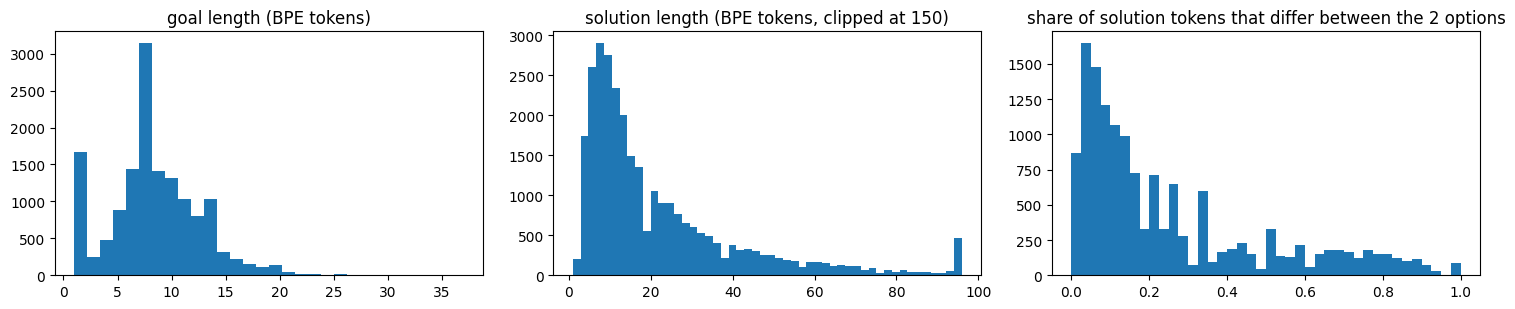

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

def split_stats(ds):
    goal_len = [sum(1 for s in it[0][1] if s == 0) - 2 for it in ds.items]
    sol_len = [sum(it[k][3]) for it in ds.items for k in (0, 1)]
    diff_share = [np.mean([t == TAG_DIFF for k in (0, 1) for t, m in zip(it[k][2], it[k][3]) if m] or [0]) for it in ds.items]
    return goal_len, sol_len, diff_share

rows = []
for split in ("train", "val", "test"):
    g, s, d = split_stats(DATA[f"{split}_ds"])
    rows.append({"split": split, "items": len(DATA[f"{split}_ds"]),
                 "label=1 share": np.mean(DATA[f"{split}_ds"].labels) if (split != "test" or DATA["test_labels_loaded"]) else np.nan,  # test labels only in Step 5
                 "goal BPE len (mean)": np.mean(g), "solution BPE len (mean)": np.mean(s),
                 "solution BPE len (p99)": np.percentile(s, 99),
                 "differing-token share (median)": np.median(d)})
display(pd.DataFrame(rows).round(3))

g, s, d = split_stats(DATA["train_ds"])
fig, ax = plt.subplots(1, 3, figsize=(15, 3.2))
ax[0].hist(g, bins=30); ax[0].set_title("goal length (BPE tokens)")
ax[1].hist(np.clip(s, 0, 150), bins=50); ax[1].set_title("solution length (BPE tokens, clipped at 150)")
ax[2].hist(d, bins=40); ax[2].set_title("share of solution tokens that differ between the 2 options")
plt.tight_layout(); plt.show()

**What the statistics imply for the design.**
* Labels are balanced, so **accuracy** is an unbiased metric and chance level is 50 %.
* In the median item only a small fraction of solution tokens differ between the two options (right histogram): the answer depends on a few words (*paper strips* vs *jeans material*, *weld* vs *nail*) placed inside otherwise identical text. A model that encodes each option independently must discover this small signal on its own from only 14.5k training items. DACT therefore (i) marks the differing tokens explicitly, (ii) compares the two options with cross-attention and (iii) biases its pooling towards the differing tokens.
* Solutions are short (p99 of about 100 BPE tokens), so we truncate solutions to 96 and goals to 40 tokens.

# 2. Model Implementation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

## 2.1 DACT: Difference-Aware Contrastive Transformer

```
 goal + sol1 ─┐                                     ┌─ diff-guided attention pooling ─┐
              ├─ shared Transformer encoder ─ h1 ─┐ │                                 ├─ scorer → s1 ┐
 tags(sol1)  ─┘   (token+pos+segment+DIFF-TAG)    ├─┤ contrastive cross-solution attn │              ├─ softmax → P(option)
 goal + sol2 ─┐                                   │ │   h_i attends to h_j, fuse      │              │
              ├─ shared Transformer encoder ─ h2 ─┘ │   [h; c; h−c; h⊙c]              ├─ scorer → s2 ┘
 tags(sol2)  ─┘                                     └─────────────────────────────────┘
 sol_i uni/bigrams ─ hashed lexical weights ─────────────────────────────────────────── + w·φ(sol_i) added to s_i
```

| Component | Standard choice | Our PIQA-specific change | Why |
|---|---|---|---|
| Input embedding | token + position (+ segment) | **+ difference-tag embedding** (goal/special, shared, different) | Tells the encoder from layer 1 where the two options disagree, so it does not have to learn this from 14.5k items |
| Option interaction | options scored independently | **Contrastive cross-solution attention**: each token of option *i* attends to the tokens of option *j* (plus a `[CLS]` sink for "no counterpart"), fused ESIM-style with `[h; c; h−c; h⊙c]` | Physical plausibility is relative ("jar" vs "plate"); the comparison features encode what replaced what |
| Summary vector | `[CLS]` or mean pooling | **Difference-guided additive attention pooling** with a learned bias per tag | Puts the decision on the few decisive tokens while the pooling weights remain interpretable |
| Lexical ("wide") head | none | **Learned weight per hashed solution unigram/bigram** (2^18 buckets, starts at 0, own learning rate 1e-2, weight decay), added to each option's score, trained jointly with the Transformer | Baseline B1 shows that which words appear in a solution is a strong signal; a Transformer trained on 14.5k items uses it only indirectly. Under the pairwise softmax only the *difference* of the two lexical scores matters, so the head learns plausible vs implausible words (cf. wide & deep models, Cheng et al., 2016) |
| Objective | independent binary classification | **Pairwise softmax** over the two option scores (label smoothing 0.1) | Matches the forced-choice task |
| Encoder | post-LN Transformer | Pre-LN, shared across options, GELU, dropout 0.2 | Stable training from scratch; weight sharing makes the model **permutation-equivariant** (swapping options swaps scores, verified below), so it cannot learn a position bias |
| (optional) warm-up | none | Masked-LM warm-up on training-split text only | Compensates for the small labelled set without external data; kept only if it helps on validation |

Every component can be switched off in `Config`, which is how the ablations in Section 3 are run.

In [ ]:
"""DACT: Difference-Aware Contrastive Transformer for PIQA (trained from scratch).

Pipeline for one PIQA item (goal g, solutions s1, s2):
  1. each option is encoded as [CLS] g [SEP] s_i [SEP] by a shared Transformer encoder whose input embedding
     = token + position + segment + DIFFERENCE TAG (shared-with-other-option / unique-to-this-option);
  2. CONTRASTIVE CROSS-SOLUTION ATTENTION lets every token of s_i attend to the tokens of s_j, and fuses
     [h; c; h-c; h*c] so the representation explicitly encodes how this option differs from its rival;
  3. DIFFERENCE-GUIDED ATTENTION POOLING summarises each option with a learned bias towards differing tokens;
  4. a shared scorer produces one logit per option; the two logits compete in a softmax.
The same weights process both options, so the model is permutation-equivariant in the option order.
"""
import math

import torch
import torch.nn as nn
import torch.nn.functional as F


class MultiHeadAttention(nn.Module):
    """Multi-head scaled dot-product attention.

    Uses the fused SDPA kernel for speed during training, and an explicit implementation when the attention
    weights are requested for visualisation.
    """

    def __init__(self, d_model, n_heads, attn_dropout):
        super().__init__()
        assert d_model % n_heads == 0
        self.h, self.dh = n_heads, d_model // n_heads
        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)
        self.o = nn.Linear(d_model, d_model)
        self.p = attn_dropout

    def forward(self, x, kv, key_mask, return_attn=False):
        B, Lq, D = x.shape
        Lk = kv.size(1)
        q = self.q(x).view(B, Lq, self.h, self.dh).transpose(1, 2)
        k = self.k(kv).view(B, Lk, self.h, self.dh).transpose(1, 2)
        v = self.v(kv).view(B, Lk, self.h, self.dh).transpose(1, 2)
        mask = key_mask[:, None, None, :]          # True = may attend
        p = self.p if self.training else 0.0
        attn = None
        if return_attn:
            scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.dh)
            scores = scores.masked_fill(~mask, float("-inf"))
            attn = torch.nan_to_num(scores.float().softmax(-1)).to(q.dtype)
            out = F.dropout(attn, p, self.training) @ v
        else:
            out = F.scaled_dot_product_attention(q, k, v, attn_mask=mask, dropout_p=p)
        return self.o(out.transpose(1, 2).reshape(B, Lq, D)), attn


class EncoderLayer(nn.Module):
    """Pre-LayerNorm Transformer encoder block (more stable than post-LN when training from scratch)."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.ln1 = nn.LayerNorm(cfg.d_model)
        self.attn = MultiHeadAttention(cfg.d_model, cfg.n_heads, cfg.attn_dropout)
        self.ln2 = nn.LayerNorm(cfg.d_model)
        self.ff = nn.Sequential(nn.Linear(cfg.d_model, cfg.d_ff), nn.GELU(), nn.Dropout(cfg.dropout),
                                nn.Linear(cfg.d_ff, cfg.d_model))
        self.drop = nn.Dropout(cfg.dropout)

    def forward(self, x, key_mask, return_attn=False):
        a, w = self.attn(self.ln1(x), self.ln1(x), key_mask, return_attn)
        x = x + self.drop(a)
        x = x + self.drop(self.ff(self.ln2(x)))
        return x, w


class ContrastiveCrossSolution(nn.Module):
    """Each option's tokens attend to the rival option's solution tokens; ESIM-style comparison fusion."""

    def __init__(self, cfg: Config):
        super().__init__()
        d = cfg.d_model
        self.ln = nn.LayerNorm(d)
        self.attn = MultiHeadAttention(d, cfg.n_heads, cfg.attn_dropout)
        self.fuse = nn.Sequential(nn.Linear(4 * d, d), nn.GELU(), nn.Dropout(cfg.dropout), nn.Linear(d, d))
        self.out_ln = nn.LayerNorm(d)
        self.drop = nn.Dropout(cfg.dropout)

    def forward(self, h_self, h_other, other_key_mask, return_attn=False):
        q, kv = self.ln(h_self), self.ln(h_other)
        c, w = self.attn(q, kv, other_key_mask, return_attn)
        m = self.fuse(torch.cat([q, c, q - c, q * c], dim=-1))
        return self.out_ln(h_self + self.drop(m)), w


class GoalMatching(nn.Module):
    """Pre-registered experiment: every token attends to the goal tokens of its own option; gated fusion.

    The cross-solution block compares the two options with each other; this block scores how a solution relates to
    the goal ("does it repeat or answer the goal?"), which the analysis found missing in the p = 0.50 ties.
    """

    def __init__(self, cfg: Config):
        super().__init__()
        d = cfg.d_model
        self.ln_q = nn.LayerNorm(d)
        self.ln_kv = nn.LayerNorm(d)
        self.attn = MultiHeadAttention(d, cfg.n_heads, cfg.attn_dropout)
        self.fuse = nn.Sequential(nn.Linear(3 * d, d), nn.GELU(), nn.Dropout(cfg.dropout), nn.Linear(d, d))
        self.gate = nn.Linear(2 * d, d)
        self.out_ln = nn.LayerNorm(d)
        self.drop = nn.Dropout(cfg.dropout)

    def forward(self, h, goal_mask, return_attn=False):
        q, kv = self.ln_q(h), self.ln_kv(h)
        c, w = self.attn(q, kv, goal_mask, return_attn)
        m = self.fuse(torch.cat([q, c, q * c], dim=-1))
        g = torch.sigmoid(self.gate(torch.cat([q, c], dim=-1)))
        return self.out_ln(h + self.drop(g * m)), w


class AttentionPooling(nn.Module):
    """Additive attention pooling over solution tokens.

    mode="diff_attn": score_t = v^T tanh(W h_t) + b[tag_t]  (learned bias per difference tag)
    mode="attn":      same without the tag bias
    mode="mean":      uniform average (ablation)
    """

    def __init__(self, d_model, mode, diff_bias_init=1.0):
        super().__init__()
        self.mode = mode
        self.proj = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, 1, bias=False)
        self.tag_bias = nn.Parameter(torch.tensor([0.0, 0.0, diff_bias_init]))  # other, shared, diff

    def forward(self, h, mask, tags):
        mask = mask.clone()
        mask[~mask.any(-1), 0] = True  # empty solution -> fall back to [CLS]
        if self.mode == "mean":
            w = mask.float() / mask.float().sum(-1, keepdim=True)
        else:
            s = self.v(torch.tanh(self.proj(h))).squeeze(-1).float()
            if self.mode == "diff_attn":
                s = s + self.tag_bias[tags]
            w = s.masked_fill(~mask, float("-inf")).softmax(-1)
        pooled = torch.einsum("nl,nld->nd", w.to(h.dtype), h)
        return pooled, w


class DACT(nn.Module):
    def __init__(self, cfg: Config, vocab_size):
        super().__init__()
        self.cfg = cfg
        d = cfg.d_model
        self.tok = nn.Embedding(vocab_size, d, padding_idx=PAD)
        self.pos = nn.Embedding(cfg.max_len, d)
        self.seg = nn.Embedding(2, d)
        self.tag = nn.Embedding(3, d) if cfg.use_diff_tags else None
        self.emb_ln = nn.LayerNorm(d)
        self.emb_drop = nn.Dropout(cfg.dropout)
        self.layers = nn.ModuleList([EncoderLayer(cfg) for _ in range(cfg.n_layers)])
        self.final_ln = nn.LayerNorm(d)
        self.cross = ContrastiveCrossSolution(cfg) if cfg.use_cross_solution else None
        self.goal = GoalMatching(cfg) if getattr(cfg, "use_goal_matching", False) else None
        self.pool = AttentionPooling(d, cfg.pool_mode, cfg.tag_bias_init)
        self.scorer = nn.Sequential(nn.Linear(2 * d, d), nn.GELU(), nn.Dropout(cfg.dropout), nn.Linear(d, 1))
        # masked-LM head (only used for the optional in-domain warm-up), tied to the token embedding
        self.mlm_transform = nn.Sequential(nn.Linear(d, d), nn.GELU(), nn.LayerNorm(d))
        self.mlm_bias = nn.Parameter(torch.zeros(vocab_size))
        self.apply(self._init)
        # lexical ("wide") head: one learned weight per hashed solution unigram/bigram, starting at zero. A plain
        # parameter (not an nn.Embedding) so that AdamW weight decay regularises it like a logistic regression.
        self.lex_w = nn.Parameter(torch.zeros(cfg.lex_buckets, 1)) if cfg.use_lexical else None

    @staticmethod
    def _init(m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, std=0.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.zeros_(m.bias)
            if isinstance(m, nn.Embedding) and m.padding_idx is not None:
                with torch.no_grad():
                    m.weight[m.padding_idx].zero_()

    def encode(self, ids, seg, tags, attn_mask, return_attn=False):
        """ids/seg/tags/attn_mask: [N, L] -> hidden states [N, L, d] and per-layer self-attention."""
        L = ids.size(1)
        pos = torch.arange(L, device=ids.device)[None]
        x = self.tok(ids) + self.pos(pos) + self.seg(seg)
        if self.tag is not None:
            x = x + self.tag(tags)
        x = self.emb_drop(self.emb_ln(x))
        attns = []
        for layer in self.layers:
            x, w = layer(x, attn_mask, return_attn)
            attns.append(w)
        return self.final_ln(x), attns

    def forward(self, batch, return_attn=False):
        ids, seg, tags = batch["input_ids"], batch["segment"], batch["tags"]
        attn_mask, sol_mask = batch["attn_mask"], batch["sol_mask"]
        B, _, L = ids.shape
        N = B * 2
        h, self_attn = self.encode(ids.view(N, L), seg.view(N, L), tags.view(N, L), attn_mask.view(N, L),
                                   return_attn)
        out = {}
        if self.goal is not None:
            # keys = the goal segment of the same option ([CLS] goal [SEP]); queries = every token
            goal_mask = (seg.view(N, L) == 0) & attn_mask.view(N, L)
            h, out["goal_attn"] = self.goal(h, goal_mask, return_attn)
        h = h.view(B, 2, L, -1)
        if self.cross is not None:
            # keys = the rival's solution tokens plus its [CLS] as a "no match" sink
            key_mask = sol_mask.clone()
            key_mask[:, :, 0] = True
            h1, w12 = self.cross(h[:, 0], h[:, 1], key_mask[:, 1], return_attn)
            h2, w21 = self.cross(h[:, 1], h[:, 0], key_mask[:, 0], return_attn)
            h = torch.stack([h1, h2], dim=1)
            out["cross_attn"] = (w12, w21)
        hf = h.reshape(N, L, -1)
        pooled, pool_w = self.pool(hf, sol_mask.view(N, L), tags.view(N, L))
        feats = torch.cat([pooled, hf[:, 0]], dim=-1)            # pooled solution summary + [CLS]
        logits = self.scorer(feats).view(B, 2).float()
        if self.lex_w is not None:
            # under the pairwise softmax only the difference of the two lexical scores matters, so shared n-grams
            # cancel and the head learns which words make a solution more plausible (cf. baseline B1)
            out["lexical"] = self.lexical_score(ids.view(N, L), sol_mask.view(N, L)).view(B, 2)
            logits = logits + out["lexical"]
        out["logits"] = logits
        out["pool"] = pool_w.view(B, 2, L)
        if return_attn:
            out["self_attn"] = [w.view(B, 2, *w.shape[1:]) for w in self_attn]
        return out

    def lexical_score(self, ids, sol_mask):
        """Sum of learned weights of the hashed BPE unigrams and bigrams of each solution: [N, L] -> [N]."""
        H = self.lex_w.size(0) - 1                               # bucket 0 = padding, always weight 0
        uni = torch.where(sol_mask, 1 + (ids * 40503) % H, 0)
        pair = sol_mask[:, :-1] & sol_mask[:, 1:]
        bi = torch.where(pair, 1 + ((ids[:, :-1] * 8191 + ids[:, 1:]) * 40503 + 7919) % H, 0)
        w = F.embedding(torch.cat([uni, bi], dim=1), self.lex_w, padding_idx=0)
        return w.float().sum((1, 2))

    def mlm_logits(self, ids, seg, tags, attn_mask, selected=None):
        h, _ = self.encode(ids, seg, tags, attn_mask)
        if selected is not None:
            # The pointwise MLM head need only run at supervised positions. The encoder is unchanged.
            h = h[selected]
        return self.mlm_transform(h) @ self.tok.weight.T + self.mlm_bias


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 2.2 Baselines
| ID | Baseline | Trained from scratch? | Role |
|---|---|---|---|
| B0 | Majority class | n/a | chance level |
| B1 | TF-IDF (1-2-grams) of *sol2 − sol1* + logistic regression (C tuned on validation) | yes | How far do shallow lexical cues get? |
| B2 | 2-layer BiLSTM + additive attention, same BPE tokenizer | yes | Same budget, recurrent instead of our Transformer design |
| B3 | `roberta-base` fine-tuned with a multiple-choice head | no (pretrained) | Reference for pretrained encoders |
| B4 | `Qwen2.5-1.5B` zero-shot, length-normalised log-likelihood | no (open LLM) | Reference for LLM knowledge without any training |

In [ ]:
"""Baselines. Every number reported for these is produced by running this code (no numbers copied from papers).

B0  majority class
B1  TF-IDF of solution text + logistic regression (tests shallow lexical cues)
B2  BiLSTM + additive attention, trained from scratch with the same tokenizer (non-Transformer comparison)
B3  fine-tuned pretrained encoder (RoBERTa) with a multiple-choice head
B4  zero-shot open LLM (Qwen2.5), length-normalised log-likelihood of each solution
"""
import copy
import time
import os

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from scipy.sparse import vstack


# ---------------------------------------------------------------- B0
def majority_baseline(train_rows, rows):
    majority = int(np.mean([r["label"] for r in train_rows]) >= 0.5)
    return np.full(len(rows), majority)


# ---------------------------------------------------------------- B1
def tfidf_lr_baseline(train_rows, val_rows, test_rows=None, Cs=(0.03, 0.1, 0.3, 1.0, 3.0, 10.0)):
    """Feature vector = tfidf(sol2) - tfidf(sol1); trained on both option orders; C picked on validation."""
    vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True, lowercase=True)
    vec.fit([r[k] for r in train_rows for k in ("goal", "sol1", "sol2")])

    def feats(rows):
        return vec.transform([r["sol2"] for r in rows]) - vec.transform([r["sol1"] for r in rows])

    Xtr = feats(train_rows)
    ytr = np.array([r["label"] for r in train_rows])
    X_aug, y_aug = vstack([Xtr, -Xtr]), np.concatenate([ytr, 1 - ytr])
    Xva, yva = feats(val_rows), np.array([r["label"] for r in val_rows])
    best = None
    for C in Cs:
        clf = LogisticRegression(C=C, max_iter=2000).fit(X_aug, y_aug)
        acc = float((clf.predict(Xva) == yva).mean())
        if best is None or acc > best[0]:
            best = (acc, C, clf)
    _, C, clf = best
    result = {"C": C, "val_pred": clf.predict(Xva), "val_prob": clf.predict_proba(Xva)[:, 1],
              "vectorizer": vec, "classifier": clf}
    if test_rows is not None:
        result["test_pred"] = clf.predict(feats(test_rows))
    return result


def tfidf_lr_predict(fitted, rows):
    vec = fitted["vectorizer"]
    x = vec.transform([r["sol2"] for r in rows]) - vec.transform([r["sol1"] for r in rows])
    return fitted["classifier"].predict(x)


# ---------------------------------------------------------------- B2
class BiLSTMAttention(nn.Module):
    """Each option ([CLS] goal [SEP] sol [SEP]) -> BiLSTM -> additive attention pooling -> score."""

    def __init__(self, cfg: Config, vocab_size, hidden=256):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, cfg.d_model, padding_idx=PAD)
        self.lstm = nn.LSTM(cfg.d_model, hidden, num_layers=2, batch_first=True, bidirectional=True,
                            dropout=cfg.dropout)
        self.att_w = nn.Linear(2 * hidden, 2 * hidden)
        self.att_v = nn.Linear(2 * hidden, 1, bias=False)
        self.drop = nn.Dropout(cfg.dropout)
        self.scorer = nn.Sequential(nn.Linear(2 * hidden, hidden), nn.GELU(), nn.Dropout(cfg.dropout),
                                    nn.Linear(hidden, 1))

    def forward(self, batch, return_attn=False):
        ids, mask = batch["input_ids"], batch["attn_mask"]
        B, _, L = ids.shape
        ids, mask = ids.view(B * 2, L), mask.view(B * 2, L)
        lengths = mask.sum(-1).cpu()
        x = self.drop(self.emb(ids))
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        h, _ = self.lstm(packed)
        h, _ = nn.utils.rnn.pad_packed_sequence(h, batch_first=True, total_length=L)
        s = self.att_v(torch.tanh(self.att_w(h))).squeeze(-1).float().masked_fill(~mask, float("-inf"))
        w = s.softmax(-1)
        pooled = torch.einsum("nl,nld->nd", w.to(h.dtype), h)
        return {"logits": self.scorer(self.drop(pooled)).view(B, 2).float(), "pool": w.view(B, 2, L)}


# ---------------------------------------------------------------- B3
def encode_multiple_choice(tok, rows, max_len):
    """[goal, solution_k] pairs for a multiple-choice head: tensors of shape [items, 2, max_len] and the labels."""
    goals = [r["goal"] for r in rows for _ in range(2)]
    sols = [r[k] for r in rows for k in ("sol1", "sol2")]
    enc = tok(goals, sols, truncation=True, max_length=max_len, padding="max_length", return_tensors="pt")
    enc = {k: v.view(len(rows), 2, -1) for k, v in enc.items()}
    return enc, torch.tensor([r["label"] for r in rows])


class AtChance(Exception):
    """Raised by finetune_pretrained when validation accuracy after epoch 1 is below the declared threshold."""


def finetune_with_restart(model_name, train_rows, val_rows, test_rows, device, out_dir, seed=42, max_restarts=2,
                          **kwargs):
    """Declared restart rule for unstable fine-tuning: a seed still at chance after epoch 1 is abandoned (its log
    is kept, ending with an "abandoned" event) and re-run with seed + 1000, at most `max_restarts` times."""
    tried = []
    for attempt in range(max_restarts + 1):
        s = seed + 1000 * attempt
        try:
            out = finetune_pretrained(model_name, train_rows, val_rows, test_rows, device, out_dir, seed=s, **kwargs)
        except AtChance:
            tried.append(s)
            continue
        out.update(seed=s, restarted_from=tried)
        return out
    raise RuntimeError(f"{model_name}: seeds {tried} all stayed at chance after epoch 1")


def finetune_pretrained(model_name, train_rows, val_rows, test_rows, device, out_dir, epochs=4, lr=1e-5,
                        batch_size=16, max_len=128, seed=42, verbose=True, revision=None, chance_threshold=None):
    """Fine-tunes a pretrained encoder with a multiple-choice head; model selection on validation only.

    With chance_threshold set, raises AtChance if validation accuracy after epoch 1 is below it (see
    finetune_with_restart)."""
    from transformers import AutoModelForMultipleChoice, AutoTokenizer, get_linear_schedule_with_warmup

    set_seed(seed)
    tok = AutoTokenizer.from_pretrained(model_name, revision=revision)
    model = AutoModelForMultipleChoice.from_pretrained(model_name, revision=revision).to(device)
    logger = JsonlLogger(f"{out_dir}/logs/B3_{model_name.split('/')[-1]}_seed{seed}.jsonl")
    if os.path.exists(logger.path):
        raise FileExistsError(logger.path)
    logger.log(event="start", model=model_name, requested_revision=revision,
               resolved_revision=getattr(model.config, "_commit_hash", None), seed=seed,
               epochs=epochs, lr=lr, batch_size=batch_size, max_len=max_len,
               n_params=sum(p.numel() for p in model.parameters()), environment=environment_info(device))

    def encode(rows):
        return encode_multiple_choice(tok, rows, max_len)

    def batches(enc, y, shuffle):
        order = torch.randperm(len(y)) if shuffle else torch.arange(len(y))
        for i in range(0, len(y), batch_size):
            idx = order[i:i + batch_size]
            yield {k: v[idx].to(device) for k, v in enc.items()}, y[idx].to(device)

    @torch.no_grad()
    def predict(enc, y, with_prob=False):
        model.eval()
        logits = []
        for xb, _ in batches(enc, y, False):
            with autocast_ctx(device):
                logits.append(model(**xb).logits.float().cpu())
        logits = torch.cat(logits)
        pred = logits.argmax(-1).numpy()
        return (pred, logits.softmax(-1)[:, 1].numpy()) if with_prob else pred

    tr, ytr = encode(train_rows)
    va, yva = encode(val_rows)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    steps = epochs * ((len(ytr) + batch_size - 1) // batch_size)
    sched = get_linear_schedule_with_warmup(opt, int(0.06 * steps), steps)
    scaler = torch.amp.GradScaler("cuda", enabled=amp_dtype(device) == torch.float16)
    best_acc, best_state = -1.0, None
    for epoch in range(1, epochs + 1):
        model.train()
        if device.type == "cuda":
            torch.cuda.reset_peak_memory_stats(device)
        t0, steps = time.time(), 0
        loss_sum, grad_sum = torch.zeros((), device=device), torch.zeros((), device=device)
        for xb, yb in batches(tr, ytr, True):
            with autocast_ctx(device):
                loss = F.cross_entropy(model(**xb).logits.float(), yb)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # norm BEFORE clipping
            scaler.step(opt)
            scaler.update()
            sched.step()
            loss_sum += loss.detach()
            grad_sum += grad_norm.detach().float()
            steps += 1
        train_seconds = time.time() - t0
        val_acc = float((predict(va, yva) == yva.numpy()).mean())
        rec = logger.log(event="epoch", epoch=epoch, train_loss=float(loss_sum) / steps, val_acc=val_acc,
                         seconds=round(time.time() - t0, 1), lr=sched.get_last_lr()[0],
                         grad_norm_mean=round(float(grad_sum) / steps, 4), step_ms=round(1000 * train_seconds / steps, 1),
                         max_memory_mb=round(torch.cuda.max_memory_allocated(device) / 2 ** 20, 1) if device.type == "cuda" else None)
        if verbose:
            print(f"[B3 {model_name}] ep {epoch} loss {rec['train_loss']:.4f} val_acc {val_acc:.4f} ({rec['seconds']}s)")
        if epoch == 1 and chance_threshold is not None and val_acc < chance_threshold:
            logger.log(event="abandoned", reason=f"val acc {val_acc:.4f} < {chance_threshold} after epoch 1")
            del model
            raise AtChance(model_name, seed, val_acc)
        if val_acc > best_acc:
            best_acc, best_state = val_acc, copy.deepcopy({k: v.cpu() for k, v in model.state_dict().items()})
    model.load_state_dict(best_state)
    checkpoint = f"{out_dir}/checkpoints/B3_{model_name.split('/')[-1]}_seed{seed}"
    model.save_pretrained(checkpoint)
    tok.save_pretrained(checkpoint)
    val_pred, val_prob = predict(va, yva, with_prob=True)
    out = {"val_pred": val_pred, "val_prob": val_prob, "best_val_acc": best_acc, "checkpoint": checkpoint,
           "max_len": max_len, "batch_size": batch_size}
    if test_rows is not None:
        te, yte = encode(test_rows)
        out["test_pred"] = predict(te, yte)
    logger.log(event="end", best_val_acc=best_acc)
    del model
    return out


@torch.no_grad()
def pretrained_predict(fitted, rows, device):
    """Separate final evaluation of the locally saved validation-selected checkpoint."""
    from transformers import AutoModelForMultipleChoice, AutoTokenizer
    tok = AutoTokenizer.from_pretrained(fitted["checkpoint"])
    model = AutoModelForMultipleChoice.from_pretrained(fitted["checkpoint"]).to(device).eval()
    predictions = []
    for start in range(0, len(rows), fitted["batch_size"]):
        chunk = rows[start:start + fitted["batch_size"]]
        goals = [r["goal"] for r in chunk for _ in range(2)]
        sols = [r[k] for r in chunk for k in ("sol1", "sol2")]
        enc = tok(goals, sols, truncation=True, max_length=fitted["max_len"], padding="max_length", return_tensors="pt")
        enc = {k:v.view(len(chunk),2,-1).to(device) for k,v in enc.items()}
        with autocast_ctx(device):
            predictions.append(model(**enc).logits.argmax(-1).cpu())
    return torch.cat(predictions).numpy()


# ---------------------------------------------------------------- B4
def lm_batch(chunk, pad_id):
    """Right-padded input ids, attention mask and continuation mask for [(ids, n_continuation_tokens), ...]: only the
    last n tokens of each sequence (the solution) are scored, never the prompt or the padding."""
    L = max(len(s) for s, _ in chunk)
    ids = torch.full((len(chunk), L), pad_id, dtype=torch.long)
    cont_mask = torch.zeros((len(chunk), L), dtype=torch.bool)
    attn = torch.zeros((len(chunk), L), dtype=torch.long)
    for j, (s, n) in enumerate(chunk):
        ids[j, :len(s)] = torch.tensor(s)
        attn[j, :len(s)] = 1
        cont_mask[j, len(s) - n:len(s)] = True
    return ids, attn, cont_mask


@torch.no_grad()
def score_continuations(model, seqs, batch_size, pad_id, device, progress=None):
    """Mean log-probability of each continuation. On a CUDA out-of-memory error the batch is halved and retried
    (down to 1); the batch sizes used after each fallback are returned for the log."""
    scores, oom, i, bs = [], [], 0, batch_size
    while i < len(seqs):
        chunk = seqs[i:i + bs]
        ids, attn, cont_mask = (t.to(device) for t in lm_batch(chunk, pad_id))
        try:
            logp = model(input_ids=ids, attention_mask=attn).logits.float().log_softmax(-1)
        except torch.cuda.OutOfMemoryError:
            if bs == 1:
                raise
            bs = max(1, bs // 2)
            oom.append(bs)
            torch.cuda.empty_cache()
            continue
        tok_lp = logp[:, :-1].gather(-1, ids[:, 1:, None]).squeeze(-1)
        m = cont_mask[:, 1:].float()
        scores.append(((tok_lp * m).sum(-1) / m.sum(-1).clamp(min=1)).cpu())
        if progress is not None and (i // batch_size) % 50 == 0:
            progress(i)
        i += len(chunk)
    return torch.cat(scores), oom


@torch.no_grad()
def llm_zero_shot(model_name, rows, device, batch_size=32, verbose=True, revision=None, out_dir=None,
                  return_prob=False):
    """Chooses the solution with the higher mean token log-probability given a goal prompt (no training).

    return_prob=True also returns softmax(mean log-probs)[option 2], a score for analysis, not a calibrated probability."""
    from transformers import AutoModelForCausalLM, AutoTokenizer

    tok = AutoTokenizer.from_pretrained(model_name, revision=revision)
    dtype = amp_dtype(device) or torch.float32
    if device.type == "cuda" and verbose:
        free, total = torch.cuda.mem_get_info(device)
        print(f"[B4 {model_name}] GPU memory before loading: {free / 2**30:.1f} of {total / 2**30:.1f} GiB free; dtype {dtype}")
    model = AutoModelForCausalLM.from_pretrained(model_name, dtype=dtype, revision=revision).to(device).eval()
    if out_dir is not None:
        JsonlLogger(f"{out_dir}/logs/B4_zero_shot.jsonl").log(event="inference", model=model_name,
            requested_revision=revision, resolved_revision=getattr(model.config, "_commit_hash", None),
            n_items=len(rows), batch_size=batch_size, continuation_limit=128,
            environment=environment_info(device))
    pad_id = tok.pad_token_id if tok.pad_token_id is not None else tok.eos_token_id

    seqs = []  # (input ids, number of continuation tokens)
    for r in rows:
        prompt = tok(f"Goal: {r['goal']}\nSolution:", add_special_tokens=True).input_ids
        for k in ("sol1", "sol2"):
            cont = tok(" " + r[k], add_special_tokens=False).input_ids[:128]
            seqs.append((prompt + cont, len(cont)))
    scores, oom = score_continuations(model, seqs, batch_size, pad_id, device,
                                      progress=(lambda i: print(f"[B4 {model_name}] {i}/{len(seqs)}")) if verbose else None)
    if out_dir is not None and oom:
        JsonlLogger(f"{out_dir}/logs/B4_zero_shot.jsonl").log(event="oom_fallback", batch_sizes=oom)
    scores = scores.view(-1, 2)
    del model
    pred = scores.argmax(-1).numpy()
    return (pred, scores.softmax(-1)[:, 1].numpy()) if return_prob else pred

## 2.3 Training utilities
AdamW (β₂ = 0.98, no decay on biases/LayerNorm/embeddings), linear warm-up + cosine decay, gradient clipping, bf16 autocast on GPU, early stopping on **validation** accuracy, and a JSON-lines log for every run.

In [ ]:
"""Training loops (QA fine-tuning, optional in-domain MLM warm-up) with mixed precision and JSONL logging."""
import math
import os
import time
import json
from contextlib import nullcontext

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader


N_SPECIAL = 5  # ids < 5 are special tokens and are never masked


def to_device(batch, device):
    return {k: v.to(device, non_blocking=True) for k, v in batch.items()}


def autocast_ctx(device, enabled=True):
    dtype = amp_dtype(device) if enabled else None
    return torch.autocast("cuda", dtype=dtype) if dtype is not None else nullcontext()


def make_optimizer(model, lr, weight_decay, lex_lr=None):
    """No weight decay on biases, LayerNorm and embedding tables.

    The lexical head (if any) gets its own learning rate: a sparse linear model needs far larger steps than the
    Transformer to move away from zero within the few epochs before early stopping.
    """
    emb = {id(m.weight) for m in model.modules() if isinstance(m, torch.nn.Embedding)}
    lex = getattr(model, "lex_w", None)
    params = [p for p in model.parameters() if p.requires_grad and p is not lex]
    decay = [p for p in params if p.ndim >= 2 and id(p) not in emb]
    no_decay = [p for p in params if p.ndim < 2 or id(p) in emb]
    groups = [{"params": decay, "weight_decay": weight_decay}, {"params": no_decay, "weight_decay": 0.0}]
    if lex is not None:
        groups.append({"params": [lex], "weight_decay": weight_decay, "lr": lex_lr or lr})
    return torch.optim.AdamW(groups, lr=lr, betas=(0.9, 0.98))


def warmup_cosine(optimizer, total_steps, warmup_ratio):
    warmup = max(1, int(total_steps * warmup_ratio))

    def f(step):
        if step < warmup:
            return (step + 1) / warmup
        progress = (step - warmup) / max(1, total_steps - warmup)
        return 0.5 * (1 + math.cos(math.pi * min(1.0, progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, f)


def qa_loss(logits, labels, cfg: Config):
    if cfg.objective == "pairwise":
        return F.cross_entropy(logits, labels, label_smoothing=cfg.label_smoothing)
    target = F.one_hot(labels, 2).float() * (1 - cfg.label_smoothing) + 0.5 * cfg.label_smoothing
    return F.binary_cross_entropy_with_logits(logits, target)


@torch.no_grad()
def predict(model, loader, device, cfg=None):
    """Returns probabilities for option 2 (label 1), predictions and gold labels, ordered by dataset index."""
    model.eval()
    logits, labels, index = [], [], []
    for batch in loader:
        batch = to_device(batch, device)
        with autocast_ctx(device, cfg.amp if cfg is not None else True):
            out = model(batch)
        logits.append(out["logits"].float().cpu())
        labels.append(batch["labels"].cpu())
        index.append(batch["index"].cpu())
    logits, labels, index = torch.cat(logits), torch.cat(labels), torch.cat(index)
    order = index.argsort()
    logits, labels = logits[order], labels[order]
    result = {"prob": logits.softmax(-1)[:, 1].numpy(), "pred": logits.argmax(-1).numpy(),
              "label": labels.numpy()}
    if cfg is not None:
        result["loss"] = float(qa_loss(logits, labels, cfg))
    return result


def train_qa(model, train_loader, val_loader, cfg: Config, device, run_name, verbose=True):
    """Trains with early stopping on validation accuracy; restores and returns the best checkpoint."""
    logger = JsonlLogger(os.path.join(cfg.out_dir, "logs", f"{run_name}.jsonl"))
    ckpt = os.path.join(cfg.out_dir, "checkpoints", f"{run_name}.pt")
    if os.path.exists(ckpt) or os.path.exists(logger.path):
        raise FileExistsError(f"Run {run_name} already exists. Choose a fresh out_dir or run name; evidence is never overwritten.")
    os.makedirs(os.path.dirname(ckpt), exist_ok=True)
    model.to(device)
    opt = make_optimizer(model, cfg.lr, cfg.weight_decay, cfg.lex_lr)
    sched = warmup_cosine(opt, cfg.epochs * len(train_loader), cfg.warmup_ratio)
    scaler = torch.amp.GradScaler("cuda", enabled=cfg.amp and amp_dtype(device) == torch.float16)
    logger.log(event="start", run=run_name, config=cfg.to_dict(),
               seed=cfg.run_seed, split_seed=cfg.seed, environment=environment_info(device),
               split_sizes={"train": len(train_loader.dataset), "val": len(val_loader.dataset)},
               checkpoint=ckpt, n_params=sum(p.numel() for p in model.parameters()))
    best_acc, best_epoch, bad = -1.0, -1, 0
    history = []
    for epoch in range(1, cfg.epochs + 1):
        model.train()
        if device.type == "cuda":
            torch.cuda.reset_peak_memory_stats(device)
        # running sums stay on the device: no GPU->CPU copy per step (the finiteness check below is the only sync)
        t0, n, steps = time.time(), 0, 0
        tot_loss = torch.zeros((), device=device)
        tot_correct = torch.zeros((), device=device)
        grad_sum, grad_max = torch.zeros((), device=device), torch.zeros((), device=device)
        for batch in train_loader:
            batch = to_device(batch, device)
            with autocast_ctx(device, cfg.amp):
                out = model(batch)
            loss = qa_loss(out["logits"], batch["labels"], cfg)
            if not torch.isfinite(loss):
                raise FloatingPointError(f"Nonfinite QA loss in {run_name}, epoch {epoch}")
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)   # norm BEFORE clipping
            scaler.step(opt)
            scaler.update()
            sched.step()
            bs = batch["labels"].size(0)
            tot_loss += loss.detach().float() * bs
            tot_correct += (out["logits"].argmax(-1) == batch["labels"]).sum()
            grad_sum += grad_norm.detach().float()
            grad_max = torch.maximum(grad_max, grad_norm.detach().float())
            n += bs
            steps += 1
        train_seconds = time.time() - t0
        val = predict(model, val_loader, device, cfg)
        val_acc = float((val["pred"] == val["label"]).mean())
        rec = logger.log(event="epoch", epoch=epoch, train_loss=float(tot_loss) / n, train_acc=float(tot_correct) / n,
                         val_acc=val_acc, val_loss=val["loss"], lr=sched.get_last_lr()[0], seconds=round(time.time() - t0, 2),
                         grad_norm_mean=round(float(grad_sum) / max(steps, 1), 4), grad_norm_max=round(float(grad_max), 4),
                         step_ms=round(1000 * train_seconds / max(steps, 1), 2),
                         max_memory_mb=round(torch.cuda.max_memory_allocated(device) / 2 ** 20, 1) if device.type == "cuda" else None)
        history.append(rec)
        write_progress(cfg, step="train", run=run_name, seed=cfg.run_seed, epoch=epoch, val_acc=round(val_acc, 4),
                       best_val_acc=round(max(best_acc, val_acc), 4))
        if verbose:
            print(f"[{run_name}] ep {epoch:02d} loss {rec['train_loss']:.4f} train_acc {rec['train_acc']:.4f} "
                  f"val_acc {val_acc:.4f} ({rec['seconds']}s)")
        if val_acc > best_acc:
            best_acc, best_epoch, bad = val_acc, epoch, 0
            torch.save(model.state_dict(), ckpt)
            with open(ckpt + ".json", "w", encoding="utf-8") as stream:
                json.dump({"run": run_name, "seed": cfg.run_seed, "config": cfg.to_dict(),
                           "best_val_acc": best_acc, "best_epoch": best_epoch,
                           "selection": "maximum validation accuracy; first epoch wins ties",
                           "environment": environment_info(device)}, stream, indent=2)
        else:
            bad += 1
            if bad >= cfg.patience:
                break
    model.load_state_dict(torch.load(ckpt, map_location=device, weights_only=True))
    logger.log(event="end", best_val_acc=best_acc, best_epoch=best_epoch)
    if verbose:
        print(f"[{run_name}] best val_acc {best_acc:.4f} at epoch {best_epoch}")
    return model, history


# ----------------------------------------------------------------------------------------------
# In-domain masked-LM warm-up (training split text only; no external data)
# ----------------------------------------------------------------------------------------------
def _mlm_collate(seqs, vocab_size, mask_prob):
    L = max(len(s[0]) for s in seqs)
    ids = torch.full((len(seqs), L), PAD, dtype=torch.long)
    seg = torch.zeros_like(ids)
    tags = torch.zeros_like(ids)
    for i, (a, b, c, _) in enumerate(seqs):
        ids[i, :len(a)], seg[i, :len(b)], tags[i, :len(c)] = torch.tensor(a), torch.tensor(b), torch.tensor(c)
    labels = ids.clone()
    candidates = ids >= N_SPECIAL
    chosen = (torch.rand(ids.shape) < mask_prob) & candidates
    labels[~chosen] = -100
    r = torch.rand(ids.shape)
    inputs = ids.clone()
    inputs[chosen & (r < 0.8)] = MASK
    rand_pos = chosen & (r >= 0.8) & (r < 0.9)
    inputs[rand_pos] = torch.randint(N_SPECIAL, vocab_size, (int(rand_pos.sum()),))
    return {"input_ids": inputs, "segment": seg, "tags": tags, "attn_mask": ids != PAD, "labels": labels}


def mlm_warmup(model, train_ds, cfg: Config, device, vocab_size, run_name, verbose=True):
    logger = JsonlLogger(os.path.join(cfg.out_dir, "logs", f"{run_name}_mlm.jsonl"))
    if os.path.exists(logger.path):
        raise FileExistsError(f"MLM evidence already exists: {logger.path}")
    logger.log(event="start", run=run_name, seed=cfg.run_seed, config=cfg.to_dict(), environment=environment_info(device))
    seqs = [seq for item in train_ds.items for seq in item]
    loader = DataLoader(seqs, batch_size=cfg.batch_size * 2, shuffle=True,
                        collate_fn=lambda b: _mlm_collate(b, vocab_size, cfg.mlm_prob))
    model.to(device)
    opt = make_optimizer(model, cfg.mlm_lr, cfg.weight_decay)
    sched = warmup_cosine(opt, cfg.mlm_epochs * len(loader), cfg.warmup_ratio)
    scaler = torch.amp.GradScaler("cuda", enabled=cfg.amp and amp_dtype(device) == torch.float16)
    for epoch in range(1, cfg.mlm_epochs + 1):
        model.train()
        t0, steps = time.time(), 0
        loss_sum, grad_sum = torch.zeros((), device=device), torch.zeros((), device=device)
        for batch in loader:
            batch = to_device(batch, device)
            selected = batch["labels"] != -100
            if not selected.any():
                continue  # no supervised tokens: mean CE would be NaN
            with autocast_ctx(device, cfg.amp):
                logits = model.mlm_logits(batch["input_ids"], batch["segment"], batch["tags"], batch["attn_mask"], selected)
            loss = F.cross_entropy(logits.float(), batch["labels"][selected])
            if not torch.isfinite(loss):
                raise FloatingPointError(f"Nonfinite MLM loss in {run_name}, epoch {epoch}")
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scaler.step(opt)
            scaler.update()
            sched.step()
            loss_sum += loss.detach()
            grad_sum += grad_norm.detach().float()
            steps += 1
        rec = logger.log(event="mlm_epoch", epoch=epoch, loss=float(loss_sum) / steps if steps else None,
                         seconds=round(time.time() - t0, 2), grad_norm_mean=round(float(grad_sum) / max(steps, 1), 4))
        if verbose:
            print(f"[{run_name} MLM] ep {epoch:02d} loss {rec['loss']} ({rec['seconds']}s)")
    return model

In [ ]:
"""Evaluation metrics: accuracy, bootstrap confidence intervals, McNemar's exact test, seed aggregation."""
import math
import json
import os

import numpy as np


def save_predictions(path, rows, prediction, run, split):
    """Persist only executed predictions; probabilities are omitted if unavailable (e.g. B0)."""
    if len(rows) != len(prediction["pred"]):
        raise ValueError("Prediction count differs from dataset size")
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "x", encoding="utf-8") as stream:
        for i, (row, pred) in enumerate(zip(rows, prediction["pred"])):
            rec = {"run": run, "split": split, "index": i, "goal": row["goal"],
                   "candidate_1": row["sol1"], "candidate_2": row["sol2"],
                   "gold_label": row["label"], "predicted_label": int(pred),
                   "correct": int(pred) == row["label"]}
            if "prob" in prediction:
                p = float(prediction["prob"][i])
                rec.update(probability_candidate_1=1-p, probability_candidate_2=p)
            stream.write(json.dumps(rec, ensure_ascii=False) + "\n")


def calibration(prob2, labels, n_bins=15):
    """Top-label calibration of a binary choice. prob2 = P(option 2). ECE uses n_bins equal-width confidence bins
    (Guo et al., 2017): sum over bins of |accuracy - mean confidence| weighted by the bin's share of items."""
    prob2, labels = np.asarray(prob2, dtype=float), np.asarray(labels)
    pred = (prob2 > 0.5).astype(int)
    conf = np.where(pred == 1, prob2, 1 - prob2)
    correct = (pred == labels).astype(float)
    bins = np.minimum((conf * n_bins).astype(int), n_bins - 1)
    ece = sum(abs(correct[bins == b].mean() - conf[bins == b].mean()) * (bins == b).mean()
              for b in range(n_bins) if (bins == b).any())
    p_gold = np.clip(np.where(labels == 1, prob2, 1 - prob2), 1e-12, 1)
    return {"accuracy": float(correct.mean()), "ece": float(ece), "mean_confidence": float(conf.mean()),
            "brier": float(np.mean((prob2 - labels) ** 2)), "nll": float(-np.log(p_gold).mean())}


def save_baseline_val(cfg, name, rows, pred, prob=None):
    """Validation predictions of a baseline (B1/B3/B4) in the same format as DACT's, also in the persistent folder."""
    out = {"pred": np.asarray(pred), **({"prob": np.asarray(prob)} if prob is not None else {})}
    for root in filter(None, (cfg.out_dir, cfg.persist_dir)):
        save_predictions(fresh_path(os.path.join(root, "predictions", f"{name}_val.jsonl")), rows, out, name, "val")


def holm_adjust(pvalues):
    """Holm family-wise correction; call on an explicitly declared comparison family."""
    p = np.asarray(pvalues, dtype=float)
    order = np.argsort(p)
    adjusted = np.empty_like(p)
    adjusted[order] = np.minimum(1, np.maximum.accumulate((len(p) - np.arange(len(p))) * p[order]))
    return adjusted


def accuracy(pred, label):
    return float((np.asarray(pred) == np.asarray(label)).mean())


def bootstrap_ci(pred, label, n_boot=2000, alpha=0.05, seed=0):
    """Percentile bootstrap CI for accuracy (resampling test items)."""
    correct = (np.asarray(pred) == np.asarray(label)).astype(float)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(correct), size=(n_boot, len(correct)))
    accs = correct[idx].mean(1)
    return float(np.quantile(accs, alpha / 2)), float(np.quantile(accs, 1 - alpha / 2))


def mcnemar_exact(pred_a, pred_b, label):
    """Exact two-sided McNemar test on the discordant pairs (binomial with p=0.5).

    b = items A gets right and B gets wrong, c = the reverse. Returns (b, c, p_value).
    """
    ca = np.asarray(pred_a) == np.asarray(label)
    cb = np.asarray(pred_b) == np.asarray(label)
    b, c = int((ca & ~cb).sum()), int((~ca & cb).sum())
    n = b + c
    if n == 0:
        return b, c, 1.0
    k = min(b, c)
    p = sum(math.comb(n, i) for i in range(k + 1)) / 2 ** n
    return b, c, min(1.0, 2 * p)


def error_overlap(pred_a, pred_b, label):
    """How two models' errors overlap: shares of items both / only A / only B / neither get right.

    `oracle` is the accuracy if we always picked whichever model is right, an upper bound on what combining
    them could achieve; a large gap to both models means they have learned different cues.
    """
    ca = np.asarray(pred_a) == np.asarray(label)
    cb = np.asarray(pred_b) == np.asarray(label)
    return {"both correct": float((ca & cb).mean()), "only A": float((ca & ~cb).mean()),
            "only B": float((~ca & cb).mean()), "both wrong": float((~ca & ~cb).mean()),
            "agreement": float((np.asarray(pred_a) == np.asarray(pred_b)).mean()),
            "oracle": float((ca | cb).mean())}


def summarise_seeds(accs):
    accs = np.asarray(accs, dtype=float)
    return {"mean": float(accs.mean()), "std": float(accs.std(ddof=1)) if len(accs) > 1 else 0.0,
            "runs": [float(a) for a in accs]}

In [ ]:
# Sanity checks: parameter count, output shapes, permutation equivariance of DACT
set_seed(0)
_m = DACT(CFG, DATA["vocab_size"]).to(DEVICE).eval()
print(f"DACT parameters: {count_parameters(_m) / 1e6:.2f}M | BiLSTM baseline: {count_parameters(BiLSTMAttention(CFG, DATA['vocab_size'])) / 1e6:.2f}M")
_items = [DATA["train_ds"][i] for i in range(8)]
_b = to_device(collate(_items), DEVICE)
_swapped = to_device(collate([((it[1], it[0]), 1 - y, i) for it, y, i in _items]), DEVICE)
with torch.no_grad():
    _o, _os = _m(_b, return_attn=True), _m(_swapped)
print("logits:", tuple(_o["logits"].shape), "| pooling:", tuple(_o["pool"].shape),
      "| self-attn per layer:", tuple(_o["self_attn"][0].shape))
print("swap option order -> scores swap:", torch.allclose(_o["logits"], _os["logits"].flip(-1), atol=1e-4))
del _m

DACT parameters: 6.38M | BiLSTM baseline: 5.07M


logits: (8, 2) | pooling: (8, 2, 46) | self-attn per layer: (8, 2, 4, 46, 46)
swap option order -> scores swap: True


# 3.Testing and Evaluation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

## 3.1 Experimental protocol
* **Metric: accuracy** (official PIQA metric; the labels are balanced and each item has exactly one correct option, so accuracy is also the expected 0/1 forced-choice score). For every from-scratch model, and for the fine-tuned RoBERTa baseline, we report **mean ± std over 3 seeds**. For the test split we also report a **95 % bootstrap CI** and an **exact McNemar test** against DACT, both computed on the seed with the best *validation* accuracy.
* **Selection:** hyper-parameters are chosen on validation (Step 1). The ablations (Step 3) change one component of the selected configuration at a time, with 3 seeds each.
* **Test:** test labels are used only in Step 5, which loads the saved checkpoints and evaluates every model once. The test file is loaded and tokenised at the start, and B1/B3 compute their test predictions in Step 4 (held unseen until Step 5); no selection uses test data. An audit found one test item that also appears in the training file (see `docs/PROJECT_AUDIT.md`); it is disclosed, not removed, so that all runs share the same split.

In [ ]:
"""Experiment orchestration: multi-seed training, validation-only selection, and a separate final test pass."""
import glob
import json
import os
import shutil
import time

import numpy as np
import torch


ARCHS = {"dact": DACT, "bilstm": BiLSTMAttention}


def build_model(arch, cfg, vocab_size):
    return ARCHS[arch](cfg, vocab_size)


def _identity(config):
    """The parts of a config that define an experiment: run_seed is set per seed; out_dir and persist_dir are only
    locations (a run restored on a new VM, or into a new folder, is the same experiment)."""
    return {k: v for k, v in config.items() if k not in ("run_seed", "out_dir", "persist_dir")}


def _load_finished(name, cfg, seeds):
    """Returns the saved validation result of `name` if it finished with the same config, seeds and checkpoints."""
    path = os.path.join(cfg.out_dir, "results", f"{name}_val.json")
    if not os.path.isfile(path):
        return None
    with open(path) as f:
        res = json.load(f)
    same = _identity(res["config"]) == _identity(cfg.to_dict()) and [r["seed"] for r in res["runs"]] == list(seeds)
    for r in res["runs"]:  # checkpoints are found relative to the current out_dir (it may be restored on a new VM)
        r["ckpt"] = _ckpt_path(cfg, f"{name}_seed{r['seed']}")
    return res if same and all(os.path.isfile(r["ckpt"]) for r in res["runs"]) else None


def _ckpt_path(cfg, run_name):
    return os.path.join(cfg.out_dir, "checkpoints", f"{run_name}.pt")


# ---- persistence across VMs -------------------------------------------------------------------------------
def _artifacts(root, name, run_name=None):
    """Files that belong to experiment `name` (or only to one seed, `run_name`) below `root`."""
    stem = run_name or f"{name}_seed*"
    patterns = [f"results/{stem}_done.json", f"logs/{stem}.jsonl", f"logs/{stem}_mlm.jsonl",
                f"predictions/{stem}_val.jsonl", f"checkpoints/{stem}.pt", f"checkpoints/{stem}.pt.json"]
    if run_name is None:
        patterns.append(f"results/{name}_val.json")
    return sorted({p for pat in patterns for p in glob.glob(os.path.join(root, pat))})


def _copy_new(files, src_root, dst_root):
    """Copies files keeping their relative paths; an existing destination is never overwritten (evidence)."""
    for path in files:
        dst = os.path.join(dst_root, os.path.relpath(path, src_root))
        if not os.path.exists(dst):
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            shutil.copy2(path, dst)


def persist(cfg, name, run_name=None):
    """Copies a finished seed (or experiment) to cfg.persist_dir, e.g. Google Drive, so a lost VM loses nothing."""
    if cfg.persist_dir:
        _copy_new(_artifacts(cfg.out_dir, name, run_name), cfg.out_dir, cfg.persist_dir)


def restore(cfg, name):
    """On a new VM: copies everything already persisted for `name` back into cfg.out_dir."""
    if cfg.persist_dir and os.path.isdir(cfg.persist_dir):
        _copy_new(_artifacts(cfg.persist_dir, name), cfg.persist_dir, cfg.out_dir)


def _load_seed(cfg, run_name):
    """A seed that finished earlier (completion marker with the same config and its checkpoint), or None."""
    marker = os.path.join(cfg.out_dir, "results", f"{run_name}_done.json")
    if not os.path.isfile(marker):
        return None
    with open(marker, encoding="utf-8") as f:
        done = json.load(f)
    if _identity(done["config"]) != _identity(cfg.to_dict()):
        raise FileExistsError(f"{run_name} already finished with a different config in {cfg.out_dir}. "
                              "Use a new out_dir / RUN_ID; evidence is never overwritten.")
    done["run"]["ckpt"] = _ckpt_path(cfg, run_name)
    return done["run"] if os.path.isfile(done["run"]["ckpt"]) else None


def _check_stale_summary(cfg, name):
    """A summary that cannot be resumed: refuse if it belongs to another config, otherwise keep it renamed."""
    path = os.path.join(cfg.out_dir, "results", f"{name}_val.json")
    if not os.path.isfile(path):
        return
    with open(path, encoding="utf-8") as f:
        old = json.load(f)
    if _identity(old["config"]) != _identity(cfg.to_dict()):
        raise FileExistsError(f"{name} already finished with a different config in {cfg.out_dir}. "
                              "Use a new out_dir / RUN_ID; evidence is never overwritten.")
    os.replace(path, path[:-len(".json")] + f".stale-{time.strftime('%Y%m%d_%H%M%S')}.json")


def _quarantine_partial(cfg, name, run_name):
    """Renames the files of an interrupted seed to *.partial-<time>.* so training can restart without
    overwriting (or deleting) the evidence of the failed attempt."""
    stamp = time.strftime("%Y%m%d_%H%M%S")
    moved = []
    for path in _artifacts(cfg.out_dir, name, run_name):
        if path.endswith("_done.json"):
            continue
        base, ext = (path[:-len(".pt.json")], ".pt.json") if path.endswith(".pt.json") else os.path.splitext(path)
        target = f"{base}.partial-{stamp}{ext}"
        os.replace(path, target)
        moved.append(target)
    return moved


def run_experiment(name, cfg, arch, data, device, seeds, verbose=True, resume=True):
    """Trains `arch` with each seed. Only the validation split is touched; checkpoints are kept for the test pass.

    With resume=True, finished work (same config, seeds and checkpoints) is loaded instead of retrained: a whole
    experiment, or single seeds of a half-finished one. With cfg.persist_dir set (e.g. Google Drive), every
    finished seed is copied there and restored on a new VM, so a reclaimed Colab session loses at most one seed.
    The files of an interrupted seed are renamed to *.partial-<time>.* and kept as evidence.
    """
    if resume:
        restore(cfg, name)
        done = _load_finished(name, cfg, seeds)
        if done is not None:
            if verbose:
                print(f"==> {name}: already finished, loaded (val acc {done['val']['mean']:.4f})")
            return done
        _check_stale_summary(cfg, name)
    runs = []
    for seed in seeds:
        cfg = cfg.but(run_seed=seed)
        run_name = f"{name}_seed{seed}"
        if resume:
            finished = _load_seed(cfg, run_name)
            if finished is not None:
                if verbose:
                    print(f"[{run_name}] already finished, loaded (val acc {finished['val_acc']:.4f})")
                runs.append(finished)
                continue
            moved = _quarantine_partial(cfg, name, run_name)
            if moved and verbose:
                print(f"[{run_name}] interrupted earlier; kept its files as {[os.path.basename(m) for m in moved]}")
        write_progress(cfg, step="experiment", experiment=name, seed=seed)
        set_seed(seed, cfg.deterministic)
        model = build_model(arch, cfg, data["vocab_size"])
        if verbose and seed == seeds[0]:
            print(f"{name}: {count_parameters(model) / 1e6:.2f}M trainable parameters")
        if arch == "dact" and cfg.mlm_epochs > 0:
            model = mlm_warmup(model, data["train_ds"], cfg, device, data["vocab_size"], run_name, verbose)
        train_loader = make_loader(data["train_ds"], cfg, True, device)
        val_loader = make_loader(data["val_ds"], cfg, False, device)
        model, history = train_qa(model, train_loader, val_loader, cfg, device, run_name, verbose)
        val = predict(model, val_loader, device, cfg)
        save_predictions(os.path.join(cfg.out_dir, "predictions", f"{run_name}_val.jsonl"),
                         data["val_ds"].rows, val, run_name, "val")
        runs.append({"seed": seed, "ckpt": _ckpt_path(cfg, run_name),
                     "val_acc": accuracy(val["pred"], val["label"]), "val_loss": val["loss"],
                     "n_params": count_parameters(model), "epochs": len(history)})
        os.makedirs(os.path.join(cfg.out_dir, "results"), exist_ok=True)
        with open(os.path.join(cfg.out_dir, "results", f"{run_name}_done.json"), "w", encoding="utf-8") as f:
            json.dump({"run": runs[-1], "config": cfg.to_dict()}, f, indent=2)
        persist(cfg, name, run_name)
        del model
        if device.type == "cuda":
            torch.cuda.empty_cache()
    res = {"name": name, "arch": arch, "config": cfg.to_dict(), "runs": runs,
           "val": summarise_seeds([r["val_acc"] for r in runs])}
    os.makedirs(os.path.join(cfg.out_dir, "results"), exist_ok=True)
    with open(os.path.join(cfg.out_dir, "results", f"{name}_val.json"), "w", encoding="utf-8") as f:
        json.dump(res, f, indent=2)
    persist(cfg, name)
    if verbose:
        print(f"==> {name}: val acc {res['val']['mean']:.4f} +- {res['val']['std']:.4f}")
    return res


def final_eval(data, cfg, reason):
    """The ONLY place where test labels are read (data.test_labels): loads them into the test rows and dataset,
    appends a line (time, commit, reason) to test_access.log in out_dir and the persistent run folder, and opens the
    guard."""
    labels = test_labels(cfg)
    rows, ds = data["test"], data["test_ds"]
    for i, r in enumerate(rows):          # rows may be a prefix of the file (smoke mode)
        r["label"] = labels[i]
    ds.labels = [r["label"] for r in ds.rows]
    data["test_labels_loaded"] = True
    log_test_access((cfg.out_dir, cfg.persist_dir), reason, len(rows))
    globals()["FINAL_EVAL"] = True
    print(f"FINAL EVALUATION opened ({reason}); logged in test_access.log")
    return np.array([r["label"] for r in rows])


@torch.no_grad()
def test_experiment(res, data, device):
    """FINAL evaluation on the test split: loads every saved checkpoint of an experiment and predicts once."""
    # Guard: in the notebook FINAL_EVAL is False until the final-results step, so test labels cannot be read earlier.
    # (Run as a plain module, e.g. the smoke test below, FINAL_EVAL is undefined and the check is skipped.)
    if not globals().get("FINAL_EVAL", True):
        raise RuntimeError("test_experiment called before the final-results step (FINAL_EVAL is False)")
    if not data.get("test_labels_loaded", True):
        raise RuntimeError("test labels are not loaded: call final_eval(DATA, CFG, reason) first")
    cfg = Config(**res["config"])
    test_loader = make_loader(data["test_ds"], cfg, False, device)
    preds, accs = [], []
    for r in res["runs"]:
        model = build_model(res["arch"], cfg, data["vocab_size"]).to(device)
        model.load_state_dict(torch.load(r["ckpt"], map_location=device, weights_only=True))
        out = predict(model, test_loader, device, cfg)
        save_predictions(os.path.join(cfg.out_dir, "predictions", f"{res['name']}_seed{r['seed']}_test.jsonl"),
                         data["test_ds"].rows, out, f"{res['name']}_seed{r['seed']}", "test")
        preds.append(out)
        accs.append(accuracy(out["pred"], out["label"]))
        del model
    # representative run for significance tests / qualitative analysis = best validation seed (not best test)
    best = int(np.argmax([r["val_acc"] for r in res["runs"]]))
    lo, hi = bootstrap_ci(preds[best]["pred"], preds[best]["label"])
    res["test"] = summarise_seeds(accs)
    res["test"]["best_val_seed"] = res["runs"][best]["seed"]
    res["test"]["best_val_seed_acc"] = accs[best]
    res["test"]["ci95"] = [lo, hi]
    res["test_preds"] = preds[best]
    with open(os.path.join(cfg.out_dir, "results", f"{res['name']}_test.json"), "w", encoding="utf-8") as f:
        json.dump({k: v for k, v in res.items() if k != "test_preds"}, f, indent=2)
    return res

In [ ]:
"""Attention visualisation and quantitative attention statistics for DACT."""
import copy

import matplotlib.pyplot as plt
import numpy as np
import torch
import json
import textwrap
from matplotlib.gridspec import GridSpec


@torch.no_grad()
def attention_for_example(model, row, tok, cfg, device):
    """Runs one PIQA item through DACT and extracts every attention map needed for the plots (head-averaged)."""
    model.eval()
    enc = encode_example(row, tok, cfg)
    batch = to_device(collate([(enc, row["label"], 0)]), device)
    out = model(batch, return_attn=True)
    probs = out["logits"].softmax(-1)[0].cpu().numpy()
    info = {"probs": probs, "pred": int(probs.argmax()), "label": row["label"],
            "goal": row["goal"], "candidate_1": row["sol1"], "candidate_2": row["sol2"],
            "attention_note": "Head-averaged slices; goal slice excludes other keys; cross slice omits CLS sink; rows need not sum to one.",
            "options": []}
    for k in range(2):
        ids, seg, tags, sol = enc[k]
        sol_pos = [i for i, m in enumerate(sol) if m]
        goal_pos = [i for i, s in enumerate(seg) if s == 0][1:-1]  # drop [CLS] and [SEP]
        info["options"].append({
            "tokens": token_strings(tok, ids), "sol_pos": sol_pos, "goal_pos": goal_pos,
            "diff": [tags[i] == TAG_DIFF for i in sol_pos],
            "pool": out["pool"][0, k].float().cpu().numpy()[sol_pos],
            # last encoder layer: attention of solution tokens (queries) over goal tokens (keys)
            "sol2goal": out["self_attn"][-1][0, k].float().mean(0).cpu().numpy()[np.ix_(sol_pos, goal_pos)],
        })
    if "cross_attn" in out:
        w12 = out["cross_attn"][0][0].float().mean(0).cpu().numpy()
        o1, o2 = info["options"]
        info["cross12"] = w12[np.ix_(o1["sol_pos"], o2["sol_pos"])]
    return info


def _label_ticks(ax, tokens, diff, axis):
    set_ticks = ax.set_xticks if axis == "x" else ax.set_yticks
    set_labels = ax.set_xticklabels if axis == "x" else ax.set_yticklabels
    set_ticks(range(len(tokens)))
    labels = set_labels(tokens, rotation=90 if axis == "x" else 0, fontsize=8)
    for lab, d in zip(labels, diff):
        if d:
            lab.set_color("crimson")
            lab.set_fontweight("bold")


def plot_attention_case(model, row, tok, cfg, device, title="", save_path=None):
    """Four panels: pooling weights for each option, sol1->sol2 cross-attention, sol->goal self-attention.

    Tokens that differ between the two options are shown in bold red.
    """
    info = attention_for_example(model, row, tok, cfg, device)
    o1, o2 = info["options"]
    goal_tokens = [o1["tokens"][i] for i in o1["goal_pos"]]
    longest = max(len(o1["sol_pos"]), len(o2["sol_pos"]))
    fig = plt.figure(figsize=(max(15, min(28, longest * .32)), max(10, min(26, longest * .27))))
    gs = GridSpec(3, 2, height_ratios=[0.35, 1, 1], figure=fig, hspace=0.9, wspace=0.3)
    for k, o in enumerate((o1, o2)):
        ax = fig.add_subplot(gs[0, k])
        im = ax.imshow(o["pool"][None], aspect="auto", cmap="viridis", vmin=0,
                       vmax=max(float(o1["pool"].max()), float(o2["pool"].max()), 1e-8))
        fig.colorbar(im, ax=ax, fraction=.025)
        _label_ticks(ax, [o["tokens"][i] for i in o["sol_pos"]], o["diff"], "x")
        ax.set_yticks([])
        tag = " (gold)" if info["label"] == k else ""
        ax.set_title(f"Option {k + 1}{tag}: pooling attention, p={info['probs'][k]:.2f}", fontsize=10)
    if "cross12" in info:
        ax = fig.add_subplot(gs[1:, 0])
        im = ax.imshow(info["cross12"], aspect="auto", cmap="magma")
        _label_ticks(ax, [o2["tokens"][i] for i in o2["sol_pos"]], o2["diff"], "x")
        _label_ticks(ax, [o1["tokens"][i] for i in o1["sol_pos"]], o1["diff"], "y")
        ax.set_title("Cross-solution attention (rows: option 1 queries, cols: option 2 keys)", fontsize=10)
        fig.colorbar(im, ax=ax, fraction=0.03)
    for k, o in enumerate((o1, o2)):
        ax = fig.add_subplot(gs[1 + k, 1])
        im = ax.imshow(o["sol2goal"], aspect="auto", cmap="Blues")
        _label_ticks(ax, goal_tokens, [False] * len(goal_tokens), "x")
        _label_ticks(ax, [o["tokens"][i] for i in o["sol_pos"]], o["diff"], "y")
        ax.set_title(f"Option {k + 1}: last-layer attention to goal tokens", fontsize=10)
        fig.colorbar(im, ax=ax, fraction=0.03)
    verdict = "CORRECT" if info["pred"] == info["label"] else "WRONG"
    fig.suptitle(textwrap.fill(f"{title} [{verdict}] Gold: option {info['label']+1}; predicted: option {info['pred']+1}. Goal: {row['goal']}", 130), fontsize=12)
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        with open(str(save_path) + ".json", "w", encoding="utf-8") as stream:
            json.dump(info, stream, indent=2, ensure_ascii=False,
                      default=lambda x: x.tolist() if hasattr(x, "tolist") else x)
    plt.show()
    return info


@torch.no_grad()
def diff_attention_mass(model, loader, device):
    """Share of pooling attention that falls on difference-tagged tokens, per item (mean of the two options)."""
    model.eval()
    mass, correct = [], []
    for batch in loader:
        batch = to_device(batch, device)
        out = model(batch)
        is_diff = (batch["tags"] == TAG_DIFF).float()
        m = (out["pool"].float() * is_diff).sum(-1).mean(-1)  # [B]
        has_diff = is_diff.sum((-1, -2)) > 0
        mass.append(m[has_diff].cpu())
        correct.append((out["logits"].argmax(-1) == batch["labels"])[has_diff].cpu())
    return torch.cat(mass).numpy(), torch.cat(correct).numpy()


@torch.no_grad()
def diff_attention_controls(model, cfg, vocab_size, loader, device, seed=0):
    """Separates learned from built-in attention on differing tokens (mean pooling mass per condition).

    trained               : the trained model, as used for prediction
    trained, tag bias = 0 : same weights with the tag bias removed -> focus coming from learned token content only
    untrained             : a freshly initialised model -> focus produced by the initial tag bias alone
    """
    no_bias = copy.deepcopy(model)
    no_bias.pool.tag_bias.zero_()
    set_seed(seed)
    untrained = DACT(cfg, vocab_size).to(device)
    conditions = {"trained": model, "trained, tag bias = 0": no_bias, "untrained (initialisation)": untrained}
    out = {name: float(diff_attention_mass(m, loader, device)[0].mean()) for name, m in conditions.items()}
    del no_bias, untrained
    return out


@torch.no_grad()
def pooling_entropy(model, loader, device):
    """Normalised entropy of the pooling weights over each option's solution tokens (1 = uniform, 0 = one token).

    Returns per-item values (mean of the two options) and whether the item was predicted correctly.
    """
    model.eval()
    ent, correct = [], []
    for batch in loader:
        batch = to_device(batch, device)
        out = model(batch)
        w = out["pool"].float().clamp_min(1e-12)
        n = batch["sol_mask"].sum(-1).float()
        h = -(w * w.log() * batch["sol_mask"]).sum(-1) / n.clamp(min=2).log()
        keep = (n > 1).all(-1)
        ent.append(h.mean(-1)[keep].cpu())
        correct.append((out["logits"].argmax(-1) == batch["labels"])[keep].cpu())
    return torch.cat(ent).numpy(), torch.cat(correct).numpy()


@torch.no_grad()
def _layer_states(model, batch):
    """Hidden states after the embedding and after every encoder layer, for both options: list of [N, L, d]."""
    ids, seg, tags, mask = (batch[k].flatten(0, 1) for k in ("input_ids", "segment", "tags", "attn_mask"))
    pos = torch.arange(ids.size(1), device=ids.device)[None]
    x = model.tok(ids) + model.pos(pos) + model.seg(seg)
    if model.tag is not None:
        x = x + model.tag(tags)
    x = model.emb_ln(x)
    states = [x]
    for layer in model.layers:
        x, _ = layer(x, mask)
        states.append(x)
    return states


def diff_probe_by_layer(model, train_loader, eval_loader, device, max_tokens=40000, seed=0):
    """Linear probe: can a logistic regression tell differing from shared solution tokens at each layer?

    Trained on solution tokens from `train_loader` and scored (balanced accuracy, 0.5 = chance) on `eval_loader`.
    For a model without tag embeddings this shows whether the encoder works out the difference by itself; for DACT
    it shows whether the injected tag survives through the layers or fades.
    """
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import balanced_accuracy_score

    model.eval()

    def collect(loader):
        per_layer, labels, n = [[] for _ in range(len(model.layers) + 1)], [], 0
        for batch in loader:
            batch = to_device(batch, device)
            sol = batch["sol_mask"].flatten(0, 1)
            for store, s in zip(per_layer, _layer_states(model, batch)):
                store.append(s[sol].float().cpu())
            labels.append((batch["tags"].flatten(0, 1) == TAG_DIFF)[sol].cpu())
            n += int(sol.sum())
            if n >= max_tokens:
                break
        return [torch.cat(s).numpy() for s in per_layer], torch.cat(labels).numpy()

    Xtr, ytr = collect(train_loader)
    Xte, yte = collect(eval_loader)
    scores = []
    for layer, (a, b) in enumerate(zip(Xtr, Xte)):
        clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=seed).fit(a, ytr)
        scores.append({"layer": "embedding" if layer == 0 else f"encoder {layer}",
                       "balanced acc": float(balanced_accuracy_score(yte, clf.predict(b)))})
    return scores


def diff_token_share(loader):
    """Fraction of solution tokens that are difference-tagged, per item (the uniform-attention reference)."""
    shares = []
    for batch in loader:
        is_diff = (batch["tags"] == TAG_DIFF).float()
        sol = batch["sol_mask"].float()
        s = (is_diff.sum(-1) / sol.sum(-1).clamp(min=1)).mean(-1)
        has_diff = is_diff.sum((-1, -2)) > 0
        shares.append(s[has_diff])
    return torch.cat(shares).numpy()


def select_cases(pred, prob, label, k=2):
    """Picks the most confident correct, most confident wrong and most uncertain items."""
    pred, prob, label = map(np.asarray, (pred, prob, label))
    conf = np.abs(prob - 0.5)
    correct = np.where(pred == label)[0]
    wrong = np.where(pred != label)[0]
    return {
        "confident_correct": correct[np.argsort(-conf[correct])][:k].tolist(),
        "confident_wrong": wrong[np.argsort(-conf[wrong])][:k].tolist(),
        "uncertain": np.argsort(conf)[:k].tolist(),
    }

In [ ]:
import pandas as pd
SEEDS = [42] if SMOKE else [42, 43, 44]
EXP = {}        # name -> result dict of from-scratch experiments

### Step 1: hyper-parameter selection (validation only, 1 seed)
A small grid chosen after an initial run showed fast over-fitting (training accuracy far above validation accuracy after a few epochs): model size, dropout, and the in-domain MLM warm-up.

**Lexical head (selected before this grid, validation only).** After the first full run, DACT and TF-IDF + LR were level on validation (59.4 vs 59.2 %). A pilot on the validation split (`tools/pilot_lexical.py`, 3 seeds each, small configuration; the test split was not loaded) compared DACT without the head (59.4 ± 0.8 %) with the head at learning rates 3e-4 (59.5 ± 0.9), 3e-3 (60.5 ± 0.7), **1e-2 (60.9 ± 0.6)** and 3e-2 (60.6 ± 0.3). The head with `lex_lr = 1e-2` was therefore made part of DACT; the grid below and all ablations use it, and *− lexical head* measures its contribution.

In [ ]:
GRID = {
    "base (d=256, L=4, drop=0.2)": CFG,
    "small (d=128, L=2)": CFG.but(d_model=128, d_ff=512, n_layers=2),
    "base, dropout 0.3": CFG.but(dropout=0.3, attn_dropout=0.15),
    "base + MLM warm-up (10 ep)": CFG.but(mlm_epochs=1 if SMOKE else 10),
    "small + MLM warm-up (10 ep)": CFG.but(d_model=128, d_ff=512, n_layers=2, mlm_epochs=1 if SMOKE else 10),
}
grid_res = {k: run_experiment(f"hp{i}", c, "dact", DATA, DEVICE, seeds=[42]) for i, (k, c) in enumerate(GRID.items())}
display(pd.DataFrame([{"config": k, "val acc": r["val"]["mean"], "epochs run": r["runs"][0]["epochs"]}
                      for k, r in grid_res.items()]).round(4))
BEST_HP = max(grid_res, key=lambda k: grid_res[k]["val"]["mean"])
BEST_CFG = GRID[BEST_HP]
print("selected on validation:", BEST_HP)

hp0: 6.38M trainable parameters


[hp0_seed42] ep 01 loss 0.6838 train_acc 0.5620 val_acc 0.5937 (14.2s)


[hp0_seed42] ep 02 loss 0.5824 train_acc 0.7394 val_acc 0.6024 (13.27s)


[hp0_seed42] ep 03 loss 0.4684 train_acc 0.8461 val_acc 0.5968 (13.36s)


[hp0_seed42] ep 04 loss 0.4049 train_acc 0.8896 val_acc 0.6024 (13.37s)


...

[hp4_seed42] ep 08 loss 0.2796 train_acc 0.9681 val_acc 0.6024 (5.99s)


[hp4_seed42] ep 09 loss 0.2678 train_acc 0.9748 val_acc 0.5999 (6.42s)
[hp4_seed42] best val_acc 0.6185 at epoch 3


==> hp4: val acc 0.6185 +- 0.0000


,config,val acc,epochs run
0,"base (d=256, L=4, drop=0.2)",0.6179,12
1,"small (d=128, L=2)",0.6141,11
2,"base, dropout 0.3",0.6079,11
3,base + MLM warm-up (10 ep),0.6079,9
4,small + MLM warm-up (10 ep),0.6185,9


selected on validation: small + MLM warm-up (10 ep)


### Step 2: main model (selected configuration, 3 seeds)

In [ ]:
EXP["DACT (full)"] = run_experiment("dact_full", BEST_CFG, "dact", DATA, DEVICE, SEEDS)

dact_full: 1.93M trainable parameters


[dact_full_seed42 MLM] ep 01 loss 7.578538911384449 (4.7s)


[dact_full_seed42 MLM] ep 02 loss 6.254361792614586 (4.67s)


[dact_full_seed42 MLM] ep 03 loss 6.067373526723761 (5.06s)


[dact_full_seed42 MLM] ep 04 loss 5.910021175417984 (4.67s)


...

[dact_full_seed44] ep 06 loss 0.3270 train_acc 0.9397 val_acc 0.6005 (6.69s)


[dact_full_seed44] ep 07 loss 0.3018 train_acc 0.9546 val_acc 0.5999 (5.95s)


[dact_full_seed44] ep 08 loss 0.2846 train_acc 0.9659 val_acc 0.5943 (6.68s)


[dact_full_seed44] ep 09 loss 0.2713 train_acc 0.9746 val_acc 0.5893 (5.88s)
[dact_full_seed44] best val_acc 0.6110 at epoch 3


==> dact_full: val acc 0.6129 +- 0.0049


### Step 3: ablation studies (3 seeds each, one change at a time)
| Ablation | What is removed / replaced | Hypothesis tested |
|---|---|---|
| − difference tags | tag embedding removed | explicit difference marking helps |
| − cross-solution attention | options are no longer compared | comparing the options matters |
| − diff bias in pooling | additive attention pooling without tag bias | steering the pooling towards differing tokens helps |
| mean pooling | uniform average instead of attention pooling | an attention-based summary is better than a uniform one |
| pointwise objective | independent BCE per option instead of pairwise softmax | the forced-choice objective helps |
| vanilla Transformer | no tags, no cross-attention, mean pooling, no lexical head | the combined contribution of our changes |
| − MLM warm-up | (only if the selected config uses it) | in-domain pre-training on training-split text helps |
| − lexical head | no hashed n-gram weights | explicit lexical evidence adds to the neural comparison |
| diff-bias prior 0 | pooling tag bias for differing tokens starts at 0 instead of 1 | the model *learns* to focus on differing tokens, rather than the focus being built in by the initial bias |

In [ ]:
ABLATIONS = {
    "− difference tags": dict(use_diff_tags=False),
    "− cross-solution attention": dict(use_cross_solution=False),
    "− diff bias in pooling": dict(pool_mode="attn"),
    "mean pooling": dict(pool_mode="mean"),
    "pointwise objective": dict(objective="pointwise"),
    "vanilla Transformer": dict(use_diff_tags=False, use_cross_solution=False, pool_mode="mean", use_lexical=False),
    "− lexical head": dict(use_lexical=False),
}
if BEST_CFG.mlm_epochs > 0:
    ABLATIONS["− MLM warm-up"] = dict(mlm_epochs=0)
ABLATIONS["diff-bias prior 0"] = dict(tag_bias_init=0.0)   # added in revision 2
for i, (name, kw) in enumerate(ABLATIONS.items()):
    EXP[name] = run_experiment(f"abl{i}", BEST_CFG.but(**kw), "dact", DATA, DEVICE, SEEDS)

abl0: 1.93M trainable parameters


[abl0_seed42 MLM] ep 01 loss 7.60414269095973 (5.07s)


[abl0_seed42 MLM] ep 02 loss 6.285080550009744 (4.61s)


[abl0_seed42 MLM] ep 03 loss 6.056895360612033 (4.82s)


[abl0_seed42 MLM] ep 04 loss 5.885806644171999 (4.87s)


...

[abl8_seed44] ep 06 loss 0.3308 train_acc 0.9406 val_acc 0.6086 (7.36s)


[abl8_seed44] ep 07 loss 0.3055 train_acc 0.9537 val_acc 0.5999 (6.11s)


[abl8_seed44] ep 08 loss 0.2883 train_acc 0.9649 val_acc 0.5912 (6.93s)


[abl8_seed44] ep 09 loss 0.2746 train_acc 0.9708 val_acc 0.5844 (6.23s)
[abl8_seed44] best val_acc 0.6160 at epoch 3


==> abl8: val acc 0.6146 +- 0.0013


### Step 4: baselines (validation)

In [ ]:
yva = np.array([r["label"] for r in DATA["val"]])
BASE = {}   # name -> {"val_acc", "val_pred", and later "test_pred"}
BASE["B0 majority"] = {"val_pred": majority_baseline(DATA["train"], DATA["val"])}
b1 = tfidf_lr_baseline(DATA["train"], DATA["val"], DATA["test"])
BASE["B1 TF-IDF + LR"] = {"val_pred": b1["val_pred"], "held_out_test_pred": b1["test_pred"]}
save_baseline_val(CFG, "B1_tfidf_lr", DATA["val"], b1["val_pred"], b1["val_prob"])
print("B1 selected C on validation:", b1["C"])
EXP["B2 BiLSTM + attention"] = run_experiment("b2_bilstm", CFG.but(lr=1e-3, dropout=0.3), "bilstm", DATA, DEVICE, SEEDS)

B1 selected C on validation: 3.0
b2_bilstm: 5.07M trainable parameters


[b2_bilstm_seed42] ep 01 loss 0.6930 train_acc 0.5098 val_acc 0.5236 (10.74s)


[b2_bilstm_seed42] ep 02 loss 0.6911 train_acc 0.5267 val_acc 0.5310 (9.56s)


[b2_bilstm_seed42] ep 03 loss 0.6837 train_acc 0.5555 val_acc 0.5428 (8.61s)


[b2_bilstm_seed42] ep 04 loss 0.6726 train_acc 0.5760 val_acc 0.5806 (9.53s)


...

[b2_bilstm_seed44] ep 12 loss 0.5100 train_acc 0.7703 val_acc 0.5868 (8.89s)


[b2_bilstm_seed44] ep 13 loss 0.4999 train_acc 0.7828 val_acc 0.5906 (8.27s)


[b2_bilstm_seed44] ep 14 loss 0.4909 train_acc 0.7897 val_acc 0.5862 (8.86s)


[b2_bilstm_seed44] ep 15 loss 0.4757 train_acc 0.8053 val_acc 0.5918 (8.93s)
[b2_bilstm_seed44] best val_acc 0.5962 at epoch 9


==> b2_bilstm: val acc 0.5928 +- 0.0068


In [ ]:
# B3: pretrained encoder fine-tuning, 3 seeds like the from-scratch models. Model selection uses validation only;
# the test predictions are stored unseen for Step 5 (produced here only to avoid keeping 3 x 500 MB checkpoints).
# Declared restart rule (NEW, not used for the reported A100 numbers): a seed still at chance after epoch 1
# (val acc < 0.52) is abandoned, its log kept, and re-run with seed + 1000 (at most twice).
B3_NAME = "FacebookAI/roberta-base"
_tr, _va, _te = (DATA["train"][:64], DATA["val"], DATA["test"]) if SMOKE else (DATA["train"], DATA["val"], DATA["test"])
b3_runs = []
for seed in SEEDS:
    b3 = finetune_with_restart(B3_NAME, _tr, _va, _te, DEVICE, CFG.out_dir, epochs=1 if SMOKE else 4,
                               batch_size=8 if SMOKE else 32, lr=2e-5, seed=seed, chance_threshold=0.52)
    b3["val_acc"] = accuracy(b3["val_pred"], yva)
    save_baseline_val(CFG, f"B3_roberta_seed{b3['seed']}", DATA["val"], b3["val_pred"], b3["val_prob"])
    b3_runs.append(b3)
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
b3_val = [r["val_acc"] for r in b3_runs]
best_b3 = b3_runs[int(np.argmax(b3_val))]   # representative run = best validation seed, as for DACT
BASE["B3 RoBERTa-base (fine-tuned)"] = {
    "val_pred": best_b3["val_pred"], "held_out_test_pred": best_b3["test_pred"],
    "held_out_test_preds": [r["test_pred"] for r in b3_runs],
    "val_acc": float(np.mean(b3_val)), "val_std": float(np.std(b3_val, ddof=1)) if len(b3_val) > 1 else np.nan}
print("B3 val acc per seed (seed actually used):", {r["seed"]: round(r["val_acc"], 4) for r in b3_runs},
      f"| mean {np.mean(b3_val):.4f}, std {np.std(b3_val, ddof=1) if len(b3_val) > 1 else float('nan'):.4f}, "
      f"median {np.median(b3_val):.4f} | restarts: {[r['restarted_from'] for r in b3_runs if r['restarted_from']]}")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

[B3 FacebookAI/roberta-base] ep 2 loss 0.6940 val_acc 0.5230 (156.9s)


[B3 FacebookAI/roberta-base] ep 3 loss 0.6940 val_acc 0.5825 (156.8s)


[B3 FacebookAI/roberta-base] ep 4 loss 0.6935 val_acc 0.5844 (157.0s)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

B3 val acc per seed (seed actually used): {1042: 0.6526, 43: 0.5378, 44: 0.5844} | mean 0.5916, std 0.0577, median 0.5844 | restarts: [[42]]


In [ ]:
# B4: zero-shot open LLM (no training at all)
B4_NAME = "Qwen/Qwen2.5-0.5B" if SMOKE else "Qwen/Qwen2.5-1.5B"
b4_pred, b4_prob = llm_zero_shot(B4_NAME, DATA["val"], DEVICE, verbose=False, return_prob=True)
BASE["B4 Qwen2.5-1.5B (zero-shot)"] = {"val_pred": b4_pred}
save_baseline_val(CFG, "B4_qwen_zero_shot", DATA["val"], b4_pred, b4_prob)
for k, v in BASE.items():
    v.setdefault("val_acc", accuracy(v["val_pred"], yva))   # B3 already holds its mean over seeds
    print(f"{k:32s} val acc {v['val_acc']:.4f}")

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.23k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

B0 majority                      val acc 0.5000
B1 TF-IDF + LR                   val acc 0.5924
B3 RoBERTa-base (fine-tuned)     val acc 0.5916
B4 Qwen2.5-1.5B (zero-shot)      val acc 0.7816


## 3.2 Step 5: final test evaluation (the only use of test labels)

In [ ]:
# Step 5: the ONLY point where test labels are read; final_eval logs the access in test_access.log and sets FINAL_EVAL
yte = final_eval(DATA, CFG, reason="Step 5: final results of the models selected on validation")
print(f"test items: {len(yte)} | label=1 share: {yte.mean():.3f}")
for name, res in EXP.items():
    test_experiment(res, DATA, DEVICE)
BASE["B0 majority"]["test_pred"] = majority_baseline(DATA["train"], DATA["test"])
BASE["B1 TF-IDF + LR"]["test_pred"] = BASE["B1 TF-IDF + LR"]["held_out_test_pred"]
BASE["B3 RoBERTa-base (fine-tuned)"]["test_pred"] = BASE["B3 RoBERTa-base (fine-tuned)"]["held_out_test_pred"]
BASE["B3 RoBERTa-base (fine-tuned)"]["test_accs"] = [accuracy(p, yte) for p in BASE["B3 RoBERTa-base (fine-tuned)"]["held_out_test_preds"]]
BASE["B4 Qwen2.5-1.5B (zero-shot)"]["test_pred"] = llm_zero_shot(B4_NAME, DATA["test"], DEVICE, verbose=False)

ref = EXP["DACT (full)"]["test_preds"]["pred"]
def row(name, val_mean, val_std, test_mean, test_std, pred, scratch):
    lo, hi = bootstrap_ci(pred, yte)
    b, c, p = mcnemar_exact(ref, pred, yte)
    return {"model": name, "from scratch": scratch, "val acc": val_mean, "val std": val_std,
            "test acc": test_mean, "test std": test_std, "test 95% CI": f"[{lo:.3f}, {hi:.3f}]",
            "McNemar p vs DACT": p if name != "DACT (full)" else np.nan}

table = []
for name, res in EXP.items():
    table.append(row(name, res["val"]["mean"], res["val"]["std"], res["test"]["mean"], res["test"]["std"],
                     res["test_preds"]["pred"], True))
for name, v in BASE.items():
    accs = v.get("test_accs", [accuracy(v["test_pred"], yte)])
    table.append(row(name, v["val_acc"], v.get("val_std", np.nan), float(np.mean(accs)),
                     float(np.std(accs, ddof=1)) if len(accs) > 1 else np.nan, v["test_pred"],
                     name.startswith(("B0", "B1"))))
RESULTS = pd.DataFrame(table)
# how many training runs each row averages over (B0/B1 are deterministic, B4 is zero-shot: a single run is exact)
N_SEEDS = {name: len(res["runs"]) for name, res in EXP.items()}
N_SEEDS.update({name: len(v.get("test_accs", [None])) for name, v in BASE.items()})
RESULTS.insert(2, "n seeds", RESULTS["model"].map(N_SEEDS))
RESULTS["note"] = RESULTS["n seeds"].map(lambda n: "" if n > 1 else "single run: no seed std")
RESULTS.to_csv(os.path.join(CFG.out_dir, "results", "final_results.csv"), index=False)
pd.set_option("display.width", 200)
display(RESULTS.round(4))

FINAL EVALUATION opened (Step 5: final results of the models selected on validation); logged in test_access.log
test items: 1838 | label=1 share: 0.505


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

,model,from scratch,n seeds,val acc,val std,test acc,test std,test 95% CI,McNemar p vs DACT,note
0,DACT (full),True,3,0.6129,0.0049,0.6186,0.0030,"[0.596, 0.640]",NaN,
1,− difference tags,True,3,0.6104,0.0022,0.6055,0.0115,"[0.585, 0.628]",0.2598,
2,− cross-solution attention,True,3,0.6187,0.0082,0.6123,0.0068,"[0.595, 0.639]",0.9086,
3,− diff bias in pooling,True,3,0.6144,0.0009,0.6126,0.0042,"[0.593, 0.637]",0.8060,
4,mean pooling,True,3,0.6110,0.0022,0.6202,0.0054,"[0.592, 0.636]",0.7050,
5,pointwise objective,True,3,0.5964,0.0062,0.6050,0.0029,"[0.582, 0.626]",0.1209,
6,vanilla Transformer,True,3,0.5755,0.0101,0.5760,0.0096,"[0.561, 0.605]",0.0068,
7,− lexical head,True,3,0.5895,0.0101,0.6155,0.0079,"[0.601, 0.643]",0.6780,
8,− MLM warm-up,True,3,0.6137,0.0072,0.6157,0.0069,"[0.592, 0.635]",0.6049,
9,diff-bias prior 0,True,3,0.6146,0.0013,0.6121,0.0036,"[0.594, 0.638]",0.8536,


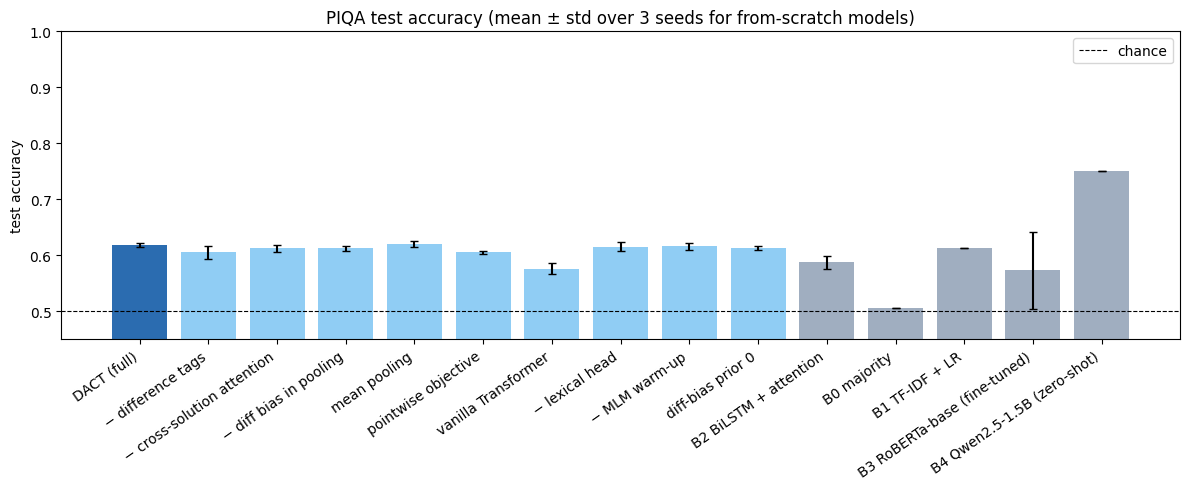

In [ ]:
order = ["DACT (full)"] + list(ABLATIONS) + ["B2 BiLSTM + attention"] + list(BASE)
R = RESULTS.set_index("model").loc[order]
fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#2b6cb0"] + ["#90cdf4"] * len(ABLATIONS) + ["#a0aec0"] * (1 + len(BASE))
ax.bar(range(len(R)), R["test acc"], yerr=R["test std"].fillna(0), color=colors, capsize=3)
ax.axhline(0.5, ls="--", c="k", lw=0.8, label="chance")
ax.set_xticks(range(len(R))); ax.set_xticklabels(R.index, rotation=35, ha="right")
ax.set_ylabel("test accuracy"); ax.set_ylim(0.45, 1.0); ax.legend()
ax.set_title("PIQA test accuracy (mean ± std over 3 seeds for from-scratch models)")
plt.tight_layout(); plt.savefig(os.path.join(CFG.out_dir, "results", "test_accuracy.png"), dpi=120); plt.show()

### Where do DACT and the baselines disagree? (error overlap)
Accuracy alone cannot tell whether DACT and TF-IDF + LR get the *same* items right. For each pair we count the test items both / only one / neither model answer correctly (representative runs, chosen on validation). A high *oracle* accuracy (right if either model is right) compared with both models means they rely on different cues; an oracle close to the better model means one model's knowledge is essentially a subset of the other's.

In [ ]:
PAIRS = {"B1 TF-IDF + LR": BASE["B1 TF-IDF + LR"]["test_pred"],
         "B2 BiLSTM + attention": EXP["B2 BiLSTM + attention"]["test_preds"]["pred"],
         "vanilla Transformer": EXP["vanilla Transformer"]["test_preds"]["pred"],
         "B3 RoBERTa-base (fine-tuned)": BASE["B3 RoBERTa-base (fine-tuned)"]["test_pred"]}
OVERLAP = pd.DataFrame({name: error_overlap(ref, pred, yte) for name, pred in PAIRS.items()}).T
OVERLAP.columns = ["both correct", "only DACT", "only other", "both wrong", "agreement", "oracle"]
OVERLAP.to_csv(os.path.join(CFG.out_dir, "results", "error_overlap.csv"))
display(OVERLAP.round(3))

,both correct,only DACT,only other,both wrong,agreement,oracle
B1 TF-IDF + LR,0.506,0.112,0.106,0.276,0.782,0.724
B2 BiLSTM + attention,0.453,0.165,0.143,0.239,0.693,0.761
vanilla Transformer,0.458,0.160,0.126,0.256,0.714,0.744
B3 RoBERTa-base (fine-tuned),0.439,0.179,0.206,0.176,0.615,0.824


In [ ]:
# Items DACT gets right and TF-IDF + LR gets wrong: what does the neural model add beyond word statistics?
only_dact = np.where((ref == yte) & (BASE["B1 TF-IDF + LR"]["test_pred"] != yte))[0]
print(f"{len(only_dact)} test items are solved by DACT but not by TF-IDF + LR; three of them:")
for j in only_dact[:3]:
    r = DATA["test"][j]
    print(f"--- test item {j} | gold = option {r['label'] + 1}\n  goal: {r['goal']}\n  sol1: {r['sol1']}\n  sol2: {r['sol2']}")

206 test items are solved by DACT but not by TF-IDF + LR; three of them:
--- test item 6 | gold = option 2
  goal: Recycle a spray bottle for a new cleaner.
  sol1: Open the top of the empty spray bottle and check for damage. Rinse the bottle then fill halfway with warm water. Replace the spray nozzle and pump a few times to clear the hose. Empty sparrow bottle and allow to dry before using with a new cleaner.
  sol2: Open the top of the empty spray bottle and check for damage. Rinse the bottle then fill halfway with warm water. Replace the spray nozzle and pump a few times to clear the hose. Empty spray bottle and allow to dry before using with a new cleaner.
--- test item 12 | gold = option 2
  goal: Find spices easily in the kitchen.
  sol1: Arrange spices from hot to mild in the kitchen in order to find them by taste.
  sol2: Arrange your spices alphabetically to make finding them easy.
--- test item 21 | gold = option 1
  goal: How to start an automatic transmission car.
  sol1: B

In [ ]:
# Every number quoted in the discussion below, in percent, straight from RESULTS (copy from here, never retype).
R = RESULTS.set_index("model")
KEY = (R[["n seeds", "val acc", "val std", "test acc", "test std"]] * [1, 100, 100, 100, 100]).round(1)
# differences of the UNROUNDED means, rounded once at the end (rounding first can shift a difference by 0.1)
KEY["val Δ vs DACT"] = (100 * (R["val acc"] - R.loc["DACT (full)", "val acc"])).round(1)
KEY["test Δ vs DACT"] = (100 * (R["test acc"] - R.loc["DACT (full)", "test acc"])).round(1)
display(KEY)

,n seeds,val acc,val std,test acc,test std,val Δ vs DACT,test Δ vs DACT
model,,,,,,,
DACT (full),3,61.3,0.5,61.9,0.3,0.0,0.0
− difference tags,3,61.0,0.2,60.6,1.1,-0.2,-1.3
− cross-solution attention,3,61.9,0.8,61.2,0.7,0.6,-0.6
− diff bias in pooling,3,61.4,0.1,61.3,0.4,0.1,-0.6
mean pooling,3,61.1,0.2,62.0,0.5,-0.2,0.2
pointwise objective,3,59.6,0.6,60.5,0.3,-1.7,-1.4
vanilla Transformer,3,57.5,1.0,57.6,1.0,-3.7,-4.3
− lexical head,3,59.0,1.0,61.6,0.8,-2.3,-0.3
− MLM warm-up,3,61.4,0.7,61.6,0.7,0.1,-0.3


### Quantitative discussion

> **Validity of the test numbers.** Validation accuracy is the only number that reflects design decisions. The test set was evaluated in several development runs, and the lexical head was introduced after earlier test results had been seen, so test numbers are reported for completeness and comparison, not as a clean held-out estimate. **On test, DACT and TF-IDF + LR are statistically tied** (61.9 vs 61.2 %, McNemar p = 0.62); DACT's advantage is on validation.
>
> **Audit checks (reproduced with `tools/verify_audit_claims.py`, `tools/rescore_without_duplicate.py`; values in `outputs/results/audit_checks.csv` and `rescore_without_duplicate.csv`).** One test item (index 1545) appears twice in our training split; re-scoring the saved test predictions without it changes accuracy by about 0.02 points (DACT 61.86 → 61.84 %, TF-IDF 61.21 → 61.19 %). 102 test items change difference tags when the two options are swapped (0 with the opt-in canonical alignment). The model overfits quickly: training accuracy is 85–92 % against about 61 % on validation at the selected epoch, and 97–98 % by the last epoch.


All numbers below are printed by the key-numbers cell above (percent; mean ± std over 3 seeds where *n seeds* = 3; differences are computed from the unrounded means).

**Main comparison.**

| Model | Val | Test |
|---|---|---|
| **DACT (ours, with lexical head)** | **61.3 ± 0.5** | **61.9 ± 0.3** |
| DACT without lexical head (ablation) | 59.0 ± 1.0 | 61.6 ± 0.8 |
| Vanilla Transformer (same budget, no DACT components, no lexical head) | 57.5 ± 1.0 | 57.6 ± 1.0 |
| B2 BiLSTM + attention | 59.3 ± 0.7 | 58.7 ± 1.1 |
| B1 TF-IDF + logistic regression | 59.2 | 61.2 |
| B3 RoBERTa-base, fine-tuned (2 of 3 seeds failed, see 3.) | 59.2 ± 5.8 | 57.3 ± 6.9 |
| B4 Qwen2.5-1.5B, zero-shot | 78.2 | 75.1 |

0. **Selected configuration.** Step 1 selected *small + MLM warm-up* (d = 128, 2 layers, 10 epochs of masked-LM training on the training split; 1.93 M parameters including the 262 k lexical weights) with 61.8 % validation accuracy, 0.06 points ahead of *base* (61.8), then *small* (61.4), *base, dropout 0.3* (60.8) and *base + MLM warm-up* (60.8). The top three are within half a point on one seed, about DACT's seed std (0.5), and the A100 run of the same code selected *small* without the warm-up: a one-seed grid cannot separate these candidates; it only rules out the clearly worse ones. Because the selected configuration uses the warm-up, Step 3 includes a *− MLM warm-up* ablation.
1. **DACT is the best from-scratch model on both splits.** It is +2.0 (val) / +0.7 (test) above TF-IDF + LR, +3.7 / +4.3 above the vanilla Transformer and +2.0 / +3.1 above the BiLSTM. On test, the gap to the vanilla Transformer is significant (McNemar p = 0.007), the gap to the BiLSTM is not (p = 0.09). The gap to TF-IDF + LR on test is small and **not significant** (p = 0.62; the 95 % CI of a single model spans about ±2.2 points), so the precise claim is that DACT is at least as good as the strong lexical baseline and above it on both splits, not that it clearly beats it.
2. **The lexical head is what closed the gap to bag-of-words.** In the run without the head, DACT was 1 point *below* TF-IDF on test (60.2 vs 61.2). The head's configuration was selected on validation only (Step 1). *Protocol note:* the decision to explore a lexical component was taken after the test results of the earlier runs had been seen, so the small test gap to TF-IDF should be read as indicative rather than as a clean held-out result (validation already showed the two level, 59.4 vs 59.2 %). Within this run, removing the head costs 2.3 (val) / 0.3 (test) points. The neural part and the lexical part are complementary: the neural model alone and the lexical baseline alone are each about 61-62 % on test, while their combination inside DACT is the best from-scratch model on validation.
3. **Pretrained knowledge remains the main gap; RoBERTa's fine-tuning failed in two seeds.** The zero-shot 1.5 B-parameter LLM is 13.2 points above DACT on test without any training on PIQA, in line with PIQA testing physical commonsense rather than reading skill. RoBERTa was unstable on the T4: seed 42 was still at chance after epoch 1 (50.7 % val) and was replaced by seed 1042 under the declared restart rule; seed 1042 learned (65.3 % val; test 95 % CI 62.4–66.6), but seeds 43 and 44 passed the 52 % threshold after epoch 1 (53.8, 52.2 %) and then stalled with their training loss at ln 2 ≈ 0.694 (53.8 and 58.4 % val). Their mean (59.2 / 57.3) therefore measures failed fine-tuning, not what RoBERTa can do: in the A100 run all three seeds trained (68.0 / 66.7). This is the known instability of fine-tuning (Dodge et al., 2020); a stricter restart rule or a lower learning rate would be the fix, decided before a new run.
4. **The result reproduces.** The A100 run of the same model (commit `0d70cdc`) gave DACT 61.2 ± 0.4 (val) / 61.6 ± 0.1 (test); this T4 run gives 61.3 ± 0.5 / 61.9 ± 0.3. Individual ablation and from-scratch baseline numbers moved by up to 1.6 points between the two runs (most notably the vanilla Transformer on test, 59.2 → 57.6), which is the scale of noise to keep in mind below.

**Ablations** (Δ vs full DACT; validation is the split used for decisions):

| Ablation | Val Δ | Test Δ |
|---|---|---|
| − lexical head | −2.3 | −0.3 |
| pointwise objective | −1.7 | −1.4 |
| − difference tags | −0.2 | −1.3 |
| mean pooling | −0.2 | +0.2 |
| − MLM warm-up | +0.1 | −0.3 |
| − diff bias in pooling | +0.1 | −0.6 |
| diff-bias prior 0 | +0.2 | −0.7 |
| − cross-solution attention | +0.6 | −0.6 |
| **vanilla (tags, cross-attention, attention pooling, lexical head all removed)** | **−3.7** | **−4.3** |

* **The design helps as a whole:** removing the tags, cross-solution attention, attention pooling and the lexical head together costs 3.7 / 4.3 points, the largest drop and the only significant one on test (p = 0.007). The **lexical head** helps clearly on validation (−2.3) and slightly on test (−0.3); the **pairwise objective** helps on both splits (−1.7 / −1.4); the **difference tags** help on test only (−0.2 / −1.3).
* **Single structural components make no consistent difference:** cross-solution attention (+0.6 / −0.6), attention pooling (mean pooling: −0.2 / +0.2), the tag bias and its initial value (+0.1 / −0.6 and +0.2 / −0.7) and the MLM warm-up (+0.1 / −0.3) move by less than a point, in opposite directions on the two splits. They overlap: the tags already tell the model where the options differ, so each of them can be replaced by the others. In the A100 run, the tags and cross-solution attention helped on both splits; with this run, only the combined effect is robust.
* Differences below about one seed std (≈ 0.1-1.1) are not conclusive; with nine single-component comparisons, the small test p-values should not be read one by one (Dror et al., 2018).

**Where DACT and TF-IDF + LR disagree.** They agree on 78.2 % of test items; DACT alone solves 11.2 % (206 items) and TF-IDF alone 10.6 %, for an oracle accuracy of 72.4 %. Agreement is higher than in the run without the head (73.5 %), as expected now that DACT contains a lexical component, yet each model still solves about 200 items the other misses. The items only DACT solves have a one-word difference inside long shared text (*release* vs *do not release* the ignition key; the typo *sparrow bottle* vs *spray bottle*), where a bag-of-words difference vector has almost nothing to work with. Against RoBERTa the oracle rises to 82.4 % (with RoBERTa's failed seeds, this understates the complementarity).


## 3.3 Qualitative analysis of attention
We analyse the best-validation-seed checkpoint of the full DACT. For each selected test item the figure shows:
1. **top row**: the difference-guided pooling weights over each option's tokens (the vector the scorer sees);
2. **bottom-left**: contrastive cross-solution attention from option-1 tokens (rows) to option-2 tokens (columns), averaged over heads;
3. **bottom-right**: last-encoder-layer attention from each option's tokens to the goal tokens.

Tokens that differ between the two options are shown in **bold red**. Cases: the two most confident correct predictions, the two most confident errors, and the most uncertain item.

In [ ]:
best_run = max(EXP["DACT (full)"]["runs"], key=lambda r: r["val_acc"])
DACT_BEST = DACT(BEST_CFG, DATA["vocab_size"]).to(DEVICE)
DACT_BEST.load_state_dict(torch.load(best_run["ckpt"], map_location=DEVICE))
DACT_BEST.eval()
tp = EXP["DACT (full)"]["test_preds"]
CASES = select_cases(tp["pred"], tp["prob"], tp["label"], k=2)
print(CASES)
os.makedirs(os.path.join(CFG.out_dir, "figures"), exist_ok=True)

{'confident_correct': [993, 1300], 'confident_wrong': [841, 747], 'uncertain': [1516, 986]}


--- confident_correct | test item 993 | gold = option 2
  goal: How to make a simple camping lantern.
  sol1: Use a 1 gallon milk jug filled with batter operated fairy lights to create a stylish and simple camping lantern.
  sol2: Simply set an empty clean 1 gallon milk jug made of translucent plastic on top of an led light. Or, you can strap a headlamp led light to the milk jug with the light facing the jug.


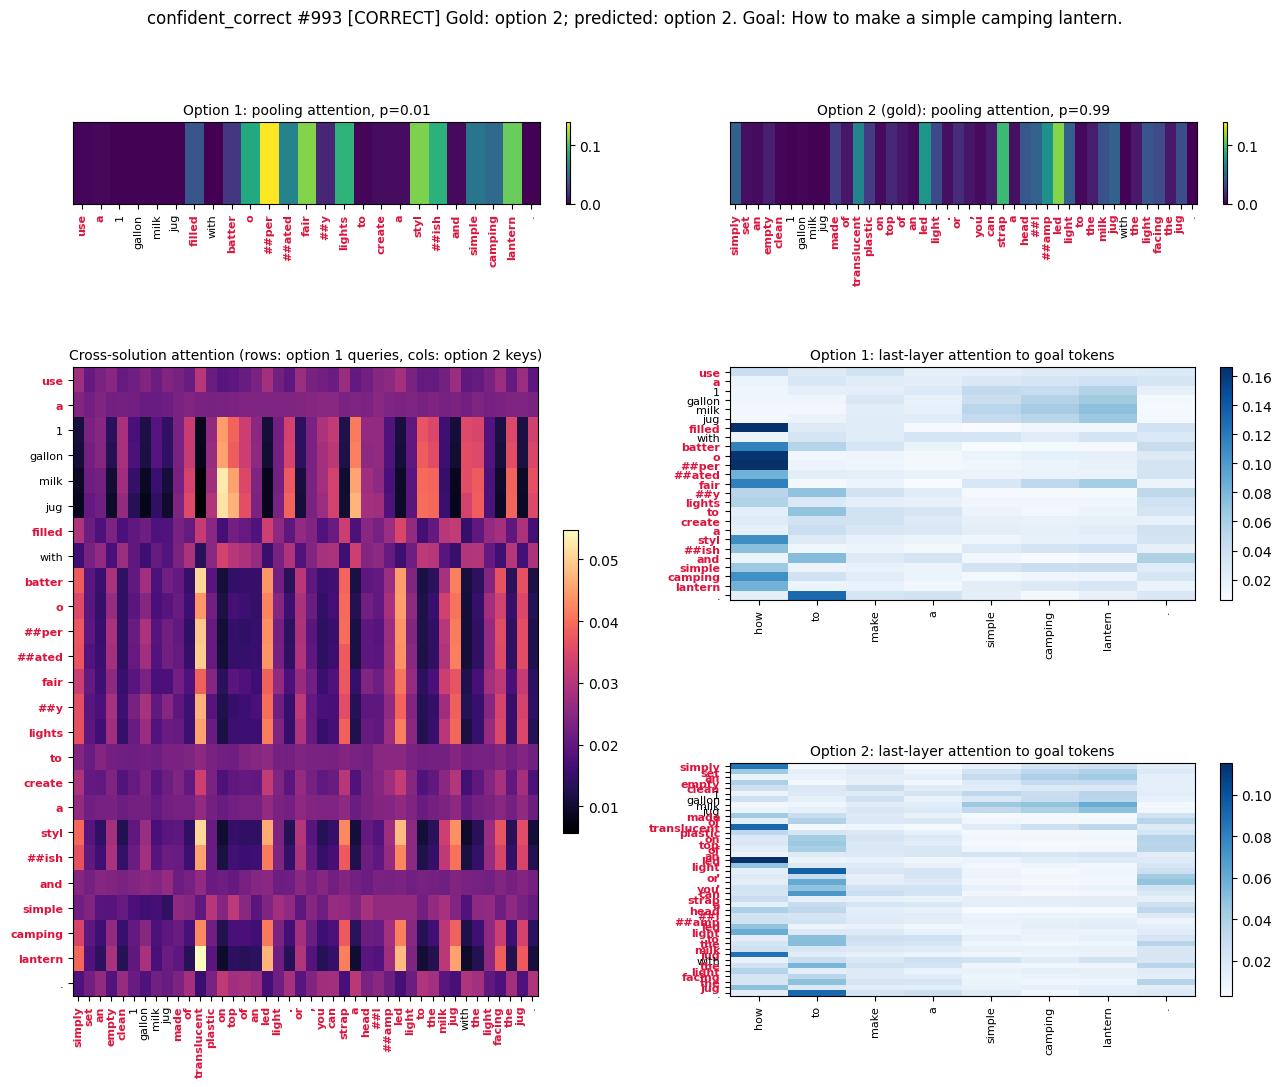

--- confident_correct | test item 1300 | gold = option 1
  goal: To become more mindful during activities,
  sol1: meditate and concentrate on everything in the present moment.
  sol2: keep your eyes closed for better focus and then try to relax and sleep.


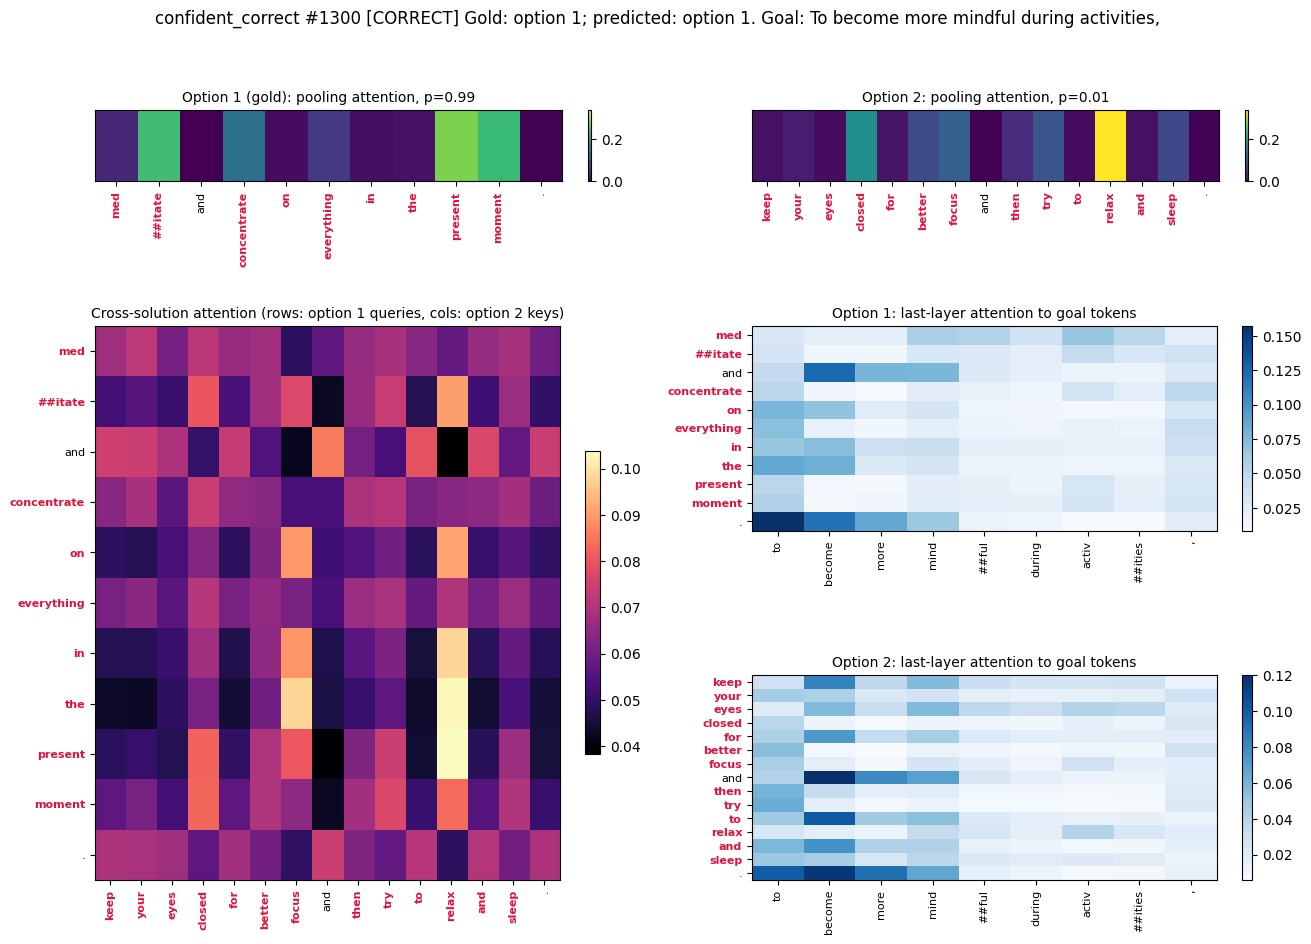

--- confident_wrong | test item 841 | gold = option 2
  goal: To make the most of an exotic trip,
  sol1: research ahead of time to create a strict itinerary of plans and stick to it diligently so that there is no free time leftover.
  sol2: don't over plan, keep things fluid so that you can explore and take advantage of any special opportunities you might find.


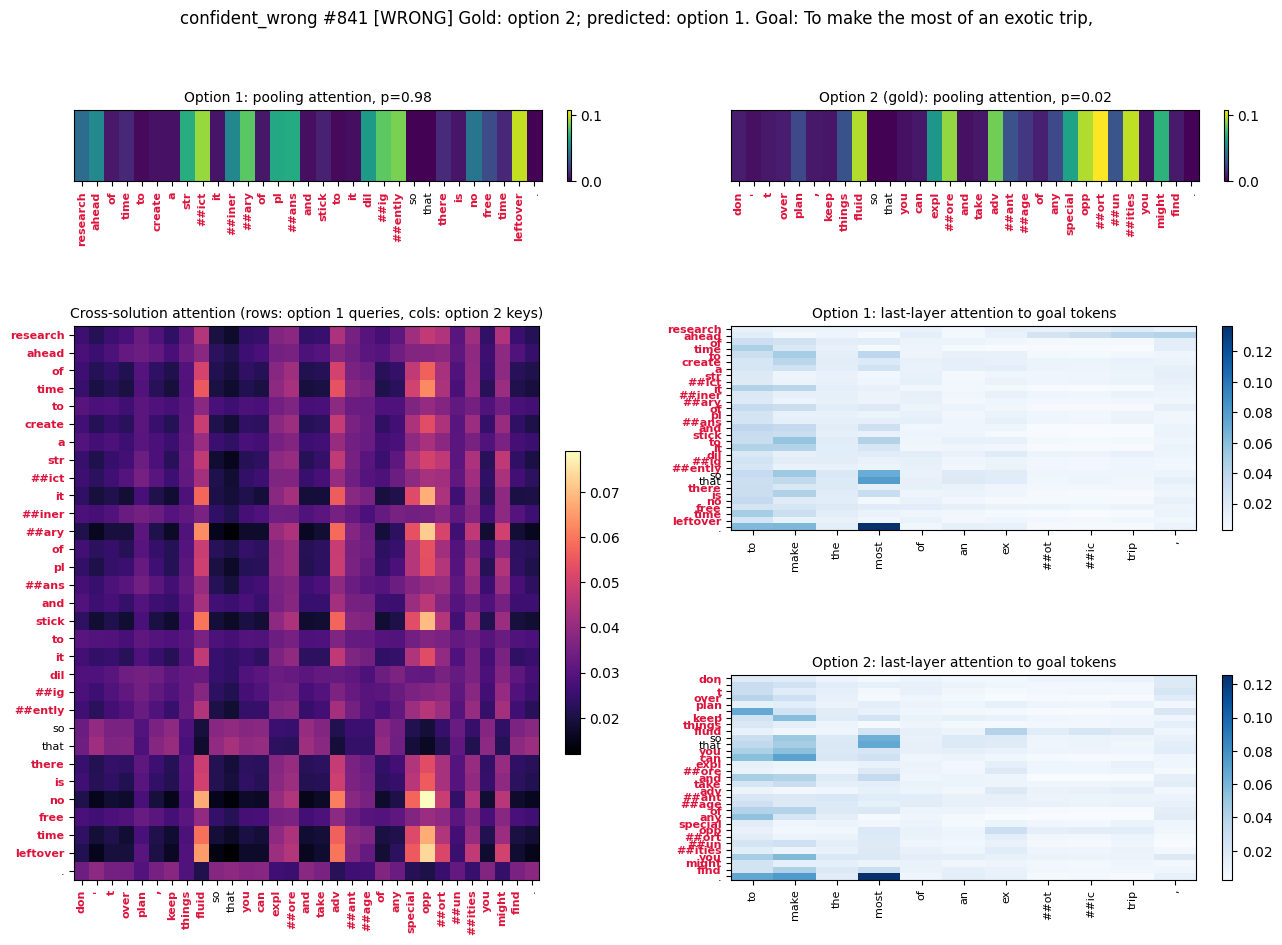

--- confident_wrong | test item 747 | gold = option 2
  goal: adding scents to lotion bars
  sol1: grate the wax and melt, in a double boiler. Add the oils to the water in the bottom of the double boiler.
  sol2: once the lotion and wax have melted, and reached the trace stage, add the scented oils and stir to combine.


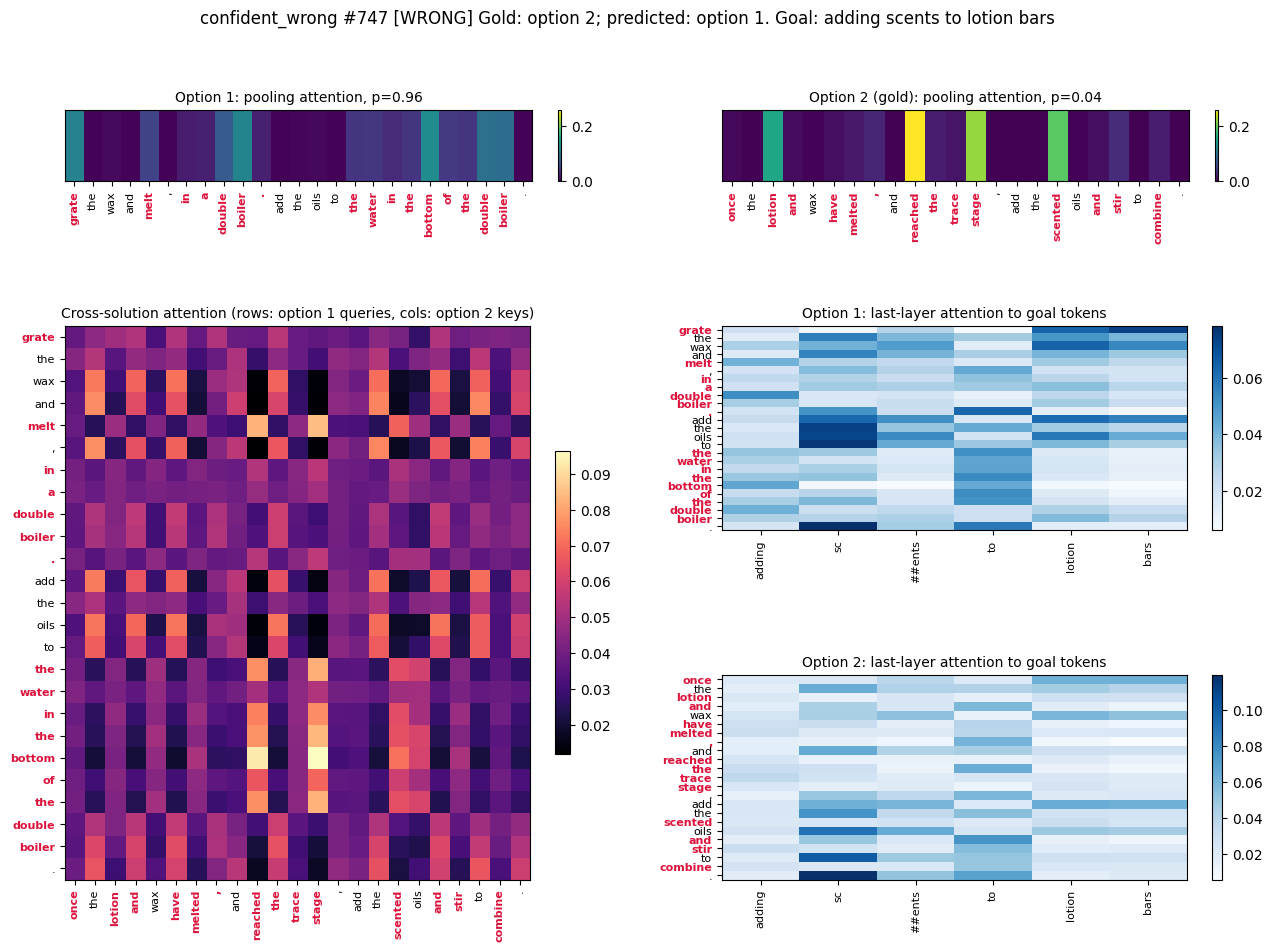

In [ ]:
for kind in ("confident_correct", "confident_wrong"):
    for i in CASES[kind]:
        r = DATA["test"][i]
        print(f"--- {kind} | test item {i} | gold = option {r['label'] + 1}\n  goal: {r['goal']}\n  sol1: {r['sol1']}\n  sol2: {r['sol2']}")
        plot_attention_case(DACT_BEST, r, DATA["tok"], BEST_CFG, DEVICE, title=f"{kind} #{i}",
                            save_path=os.path.join(CFG.out_dir, "figures", f"{kind}_{i}.png"))

--- uncertain | test item 1516 | gold = option 1
  goal: How to make a small but cheap home easily?
  sol1: Purchase a shipping container online and have it installed on a cheap rental lot, then convert the container into a living space
  sol2: Purchase a shopping container online and have it installed on a cheap rental lot, then convert the container into a relaxing environment


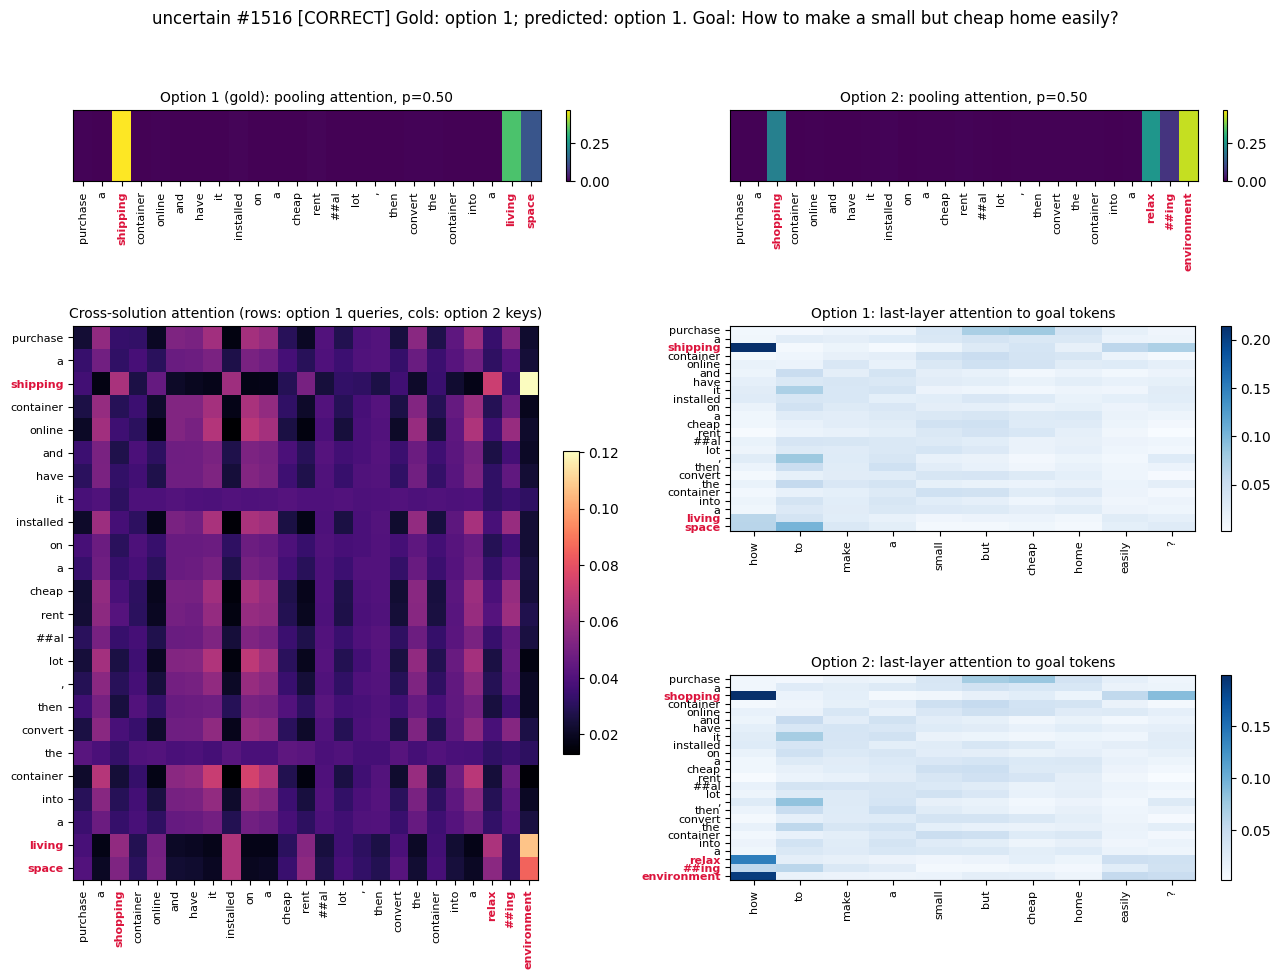

In [ ]:
i = CASES["uncertain"][0]
r = DATA["test"][i]
print(f"--- uncertain | test item {i} | gold = option {r['label'] + 1}\n  goal: {r['goal']}\n  sol1: {r['sol1']}\n  sol2: {r['sol2']}")
_ = plot_attention_case(DACT_BEST, r, DATA["tok"], BEST_CFG, DEVICE, title=f"uncertain #{i}",
                        save_path=os.path.join(CFG.out_dir, "figures", f"uncertain_{i}.png"))

### Does attention focus on the differing tokens, and does that relate to correctness?
For every test item we measure the share of pooling attention that falls on difference-tagged tokens and compare it with the share those tokens would get under uniform attention, separately for correct and wrong predictions.

**Control (revision 2).** The pooling bias for differing tokens is *initialised* at 1.0, so part of this focus is built in before any training. We therefore also measure the mass (a) of the same trained model with the tag bias set to 0, i.e. the focus coming only from the learned token representations, and (b) of an untrained model, i.e. the focus produced by the initial bias alone. The *diff-bias prior 0* ablation (Step 3) is the matching training-time control.

learned pooling tag bias [other, shared, diff]: [ 0.   -0.03  1.03]
mean attention mass on differing tokens: 0.780 (uniform-attention reference 0.248)
  correct predictions: 0.774 | wrong predictions: 0.790
  Mann-Whitney U (correct vs wrong): p = 0.03216


,mean pooling mass on differing tokens
trained,0.780
"trained, tag bias = 0",0.620
untrained (initialisation),0.389
uniform attention (reference),0.248


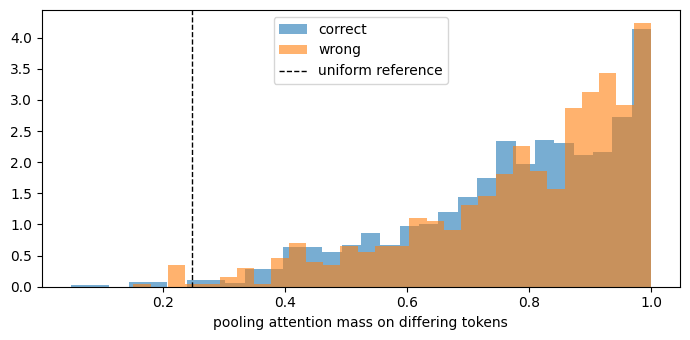

In [ ]:
from scipy.stats import mannwhitneyu
test_loader = make_loader(DATA["test_ds"], BEST_CFG, False, DEVICE)
mass, correct = diff_attention_mass(DACT_BEST, test_loader, DEVICE)
uniform = diff_token_share(test_loader)
print(f"learned pooling tag bias [other, shared, diff]: {DACT_BEST.pool.tag_bias.detach().cpu().numpy().round(3)}")
print(f"mean attention mass on differing tokens: {mass.mean():.3f} (uniform-attention reference {uniform.mean():.3f})")
print(f"  correct predictions: {mass[correct].mean():.3f} | wrong predictions: {mass[~correct].mean():.3f}")
print("  Mann-Whitney U (correct vs wrong): p = %.4g" % mannwhitneyu(mass[correct], mass[~correct]).pvalue)
CONTROLS = diff_attention_controls(DACT_BEST, BEST_CFG, DATA["vocab_size"], test_loader, DEVICE)
CONTROLS["uniform attention (reference)"] = float(uniform.mean())
display(pd.Series(CONTROLS, name="mean pooling mass on differing tokens").round(3).to_frame())
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(mass[correct], bins=30, alpha=0.6, density=True, label="correct")
ax.hist(mass[~correct], bins=30, alpha=0.6, density=True, label="wrong")
ax.axvline(uniform.mean(), c="k", ls="--", lw=1, label="uniform reference")
ax.set_xlabel("pooling attention mass on differing tokens"); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(CFG.out_dir, "figures", "diff_attention_mass.png"), dpi=120); plt.show()

### Why does DACT not beat a bag-of-words baseline? Two testable explanations
TF-IDF + LR scores at least as well as DACT on test, on a task built around lexical differences. We test two explanations on the **validation** split (no test data is used for this diagnosis):

* **H1: the pooling does not select.** If the pooling weights are close to uniform (normalised entropy near 1), the scorer sees an average over the solution, not the decisive words.
* **H2: the difference signal does not survive the encoder.** A linear probe tries to tell differing from shared solution tokens at every layer. For DACT the tag is injected at the input, so a probe score that falls with depth means the signal fades. For the vanilla Transformer (no tags), compare each layer with its *embedding* row: word identity alone already predicts some differing tokens (some words appear mostly in substituted spans), so only a rise above the embedding score shows that the encoder works out the difference from context, which is what the tags were meant to supply.

In [ ]:
val_loader = make_loader(DATA["val_ds"], BEST_CFG, False, DEVICE)
ent, ent_correct = pooling_entropy(DACT_BEST, val_loader, DEVICE)
print(f"H1  normalised pooling entropy (1 = uniform): mean {ent.mean():.3f} | correct {ent[ent_correct].mean():.3f} "
      f"| wrong {ent[~ent_correct].mean():.3f} | Mann-Whitney p = {mannwhitneyu(ent[ent_correct], ent[~ent_correct]).pvalue:.3g}")

van_res = EXP["vanilla Transformer"]
van_cfg = Config(**van_res["config"])
VANILLA = DACT(van_cfg, DATA["vocab_size"]).to(DEVICE)
VANILLA.load_state_dict(torch.load(max(van_res["runs"], key=lambda r: r["val_acc"])["ckpt"], map_location=DEVICE))
probe_train = make_loader(DATA["train_ds"], BEST_CFG, True, DEVICE)
PROBE = pd.DataFrame({
    "DACT (tags injected)": pd.DataFrame(diff_probe_by_layer(DACT_BEST, probe_train, val_loader, DEVICE)).set_index("layer")["balanced acc"],
    "vanilla (no tags)": pd.DataFrame(diff_probe_by_layer(VANILLA, probe_train, val_loader, DEVICE)).set_index("layer")["balanced acc"],
})
PROBE.to_csv(os.path.join(CFG.out_dir, "results", "diff_probe_by_layer.csv"))
print("H2  linear-probe balanced accuracy for 'differing vs shared' solution tokens (0.5 = chance):")
display(PROBE.round(3))
del VANILLA

H1  normalised pooling entropy (1 = uniform): mean 0.587 | correct 0.587 | wrong 0.587 | Mann-Whitney p = 0.985


H2  linear-probe balanced accuracy for 'differing vs shared' solution tokens (0.5 = chance):


,DACT (tags injected),vanilla (no tags)
layer,,
embedding,1.0,0.620
encoder 1,1.0,0.628
encoder 2,1.0,0.630


### Qualitative discussion

**Is the focus on differing tokens learned or built in?** The trained model puts **78.0 %** of its pooling attention on the differing tokens, which make up only 24.8 % of solution tokens. The controls separate the sources of this focus:
* an **untrained** model with the same initial bias puts 38.9 % there: the built-in prior alone gives only a modest focus;
* the **trained model with the tag bias set to 0** still puts **62.0 %** there: most of the focus comes from what the pooling scorer learned about the token representations, not from the bias;
* the bias itself hardly moved in training (differing tokens 1.0 → 1.03, shared tokens 0 → −0.03).

So the focus is genuinely learned, which is also why *diff-bias prior 0* changes little. Wrong predictions put slightly *more* attention on the differing tokens than correct ones (79.0 % vs 77.4 %, Mann-Whitney p = 0.03): **looking at the right tokens is not the bottleneck; judging them is.**

**Why the neural part alone does not beat bag-of-words (validation split).**
* *H1 (the pooling does not select)* is rejected: the normalised pooling entropy is 0.59 (1 = uniform), for correct and wrong predictions alike (0.587 vs 0.587, p = 0.98).
* *H2 (the difference signal is missing)*: in the vanilla Transformer a linear probe separates differing from shared tokens with 62.0 % balanced accuracy at the embedding layer and at most 63.0 % after the encoder layers: without tags the encoder barely works out *where* the options differ. In DACT the injected tag stays perfectly decodable in every layer (100 %). The tags therefore supply information the encoder does not learn by itself, and the lexical head supplies direct word-level evidence the encoder uses only indirectly; neither provides the physical knowledge that the pretrained baselines bring.

**A side effect of the lexical head: over-confidence on long differing spans.** All four most confident predictions (p ≥ 0.96) are pairs of options that **differ in most of their words** (61-90 % of solution tokens). The lexical score is a *sum* of n-gram weights, so a long differing span produces a large score difference whether or not the evidence is right; calibration of the head (e.g. length normalisation) is a natural next step. (On validation, DACT's expected calibration error is about 10 points, and removing the head lowers the mean confidence by about 4.5 points: `experiments/calibration/`, computed from the A100 run's predictions.)

**Success 1: "How to make a simple camping lantern", *milk jug of translucent plastic on top of an LED light / strapped headlamp* ✓ vs *milk jug filled with batter-operated fairy lights* (p = 0.99).** Nearly every token differs (19 of 25 and 36 of 42 solution tokens), so the difference tags carry little information; the pooling spreads over the whole solution (*##per*, *fair*, *styl*, *lantern* vs *led*, *strap*, *##amp*, *translucent*), and the decision rests on which words and phrases were associated with plausible solutions in training.

**Success 2: "To become more mindful during activities", *meditate and concentrate on everything in the present moment* ✓ vs *keep your eyes closed for better focus and then try to relax and sleep* (p = 0.99).** The pooling picks *present*, *##itate*, *moment* against *relax*, *closed*, *focus*: words that co-occur with mindfulness in training text, not a judgement about whether sleeping helps one be mindful.

**Failure 1: "To make the most of an exotic trip", *research ahead to create a strict itinerary … no free time leftover* vs *don't over plan, keep things fluid … take advantage of special opportunities* (gold) (p = 0.98 for the wrong option).** The two options share almost no words (28 of 31 tokens differ on each side), so the pooling is spread over the whole of both and the lexical head sums over many n-grams: *research*, *create* and *plans* look like the vocabulary of good instructions. The item asks what makes a trip enjoyable, which no word statistic captures.

**Failure 2: "Adding scents to lotion bars", *grate the wax, melt in a double boiler, add the oils to the water in the bottom of the boiler* vs *once the lotion and wax have melted and reached the trace stage, add the scented oils and stir* (gold) (p = 0.96 for the wrong option).** The pooling of option 1 peaks on *bottom*, *boiler* and *grate*, the part that makes it wrong (oil into the water bath), and of option 2 on *reached*, *stage*, *scented* and *lotion*. The model locates the decisive spans but has no way to know that oil added to the water bath never reaches the lotion; the familiar cooking vocabulary of option 1 wins. (This item was also a confident error in the A100 run.)

**Uncertain case: "How to make a small but cheap home easily?", *purchase a shipping container … convert it into a living space* ✓ vs *purchase a shopping container … convert it into a relaxing environment* (p = 0.50).** Only 3-4 tokens differ, including a one-letter typo. The pooling finds them: almost half its weight is on *shipping* (0.47) and the rest on *living space*, against *environment*, *relax* and *shopping*. But the scores tie: the model sees the difference but does not know that shipping containers are a common cheap home and "shopping containers" are not a thing.

**Summary.** DACT learns to concentrate on the words where the options differ, the difference tags supply information the encoder does not discover alone, and the lexical head adds direct word-level evidence; together, and with the forced-choice objective, they make it the best from-scratch model on validation, while single structural components are interchangeable. The remaining errors come from judging the decisive words without physical or everyday knowledge (*oil into the water bath*, *shipping containers*) and from the head's over-confidence on long differing spans (*exotic trip*). Pretraining (B4) addresses the first; length normalisation of the lexical score addresses the second.


## Consistency check
The marking guide penalises differences between the report, the code and the logs. This cell checks that the saved result files match the tables above and that every training run left a log.

In [ ]:
import glob, subprocess
saved = pd.read_csv(os.path.join(CFG.out_dir, "results", "final_results.csv"))
assert np.allclose(saved["test acc"], RESULTS["test acc"]) and list(saved["model"]) == list(RESULTS["model"]), "final_results.csv is stale"
for name, res in EXP.items():
    with open(os.path.join(CFG.out_dir, "results", f"{res['name']}_val.json")) as f:
        assert abs(json.load(f)["val"]["mean"] - res["val"]["mean"]) < 1e-9, f"{name}: val json differs"
    for r in res["runs"]:
        assert os.path.isfile(os.path.join(CFG.out_dir, "logs", f"{res['name']}_seed{r['seed']}.jsonl")), f"missing log for {name}"
print(f"OK: {len(RESULTS)} result rows, {sum(len(r['runs']) for r in EXP.values())} training runs with logs, "
      f"{len(glob.glob(os.path.join(CFG.out_dir, 'logs', '*.jsonl')))} log files")
if os.path.isfile("tools/sync_notebook.py"):   # only when run from a checkout of the repository
    print(subprocess.run([sys.executable, "tools/sync_notebook.py", "--check"], capture_output=True, text=True).stdout)

OK: 15 result rows, 33 training runs with logs, 71 log files


In [ ]:
# Persist logs, results and figures (checkpoints excluded to save space): copy to Google Drive when it is mounted,
# and on Colab also pack them into outputs.zip and download it to the browser's computer.
import shutil
if not SMOKE and os.path.isdir("/content/drive/MyDrive"):
    dst = "/content/drive/MyDrive/Group69/outputs"
    shutil.copytree(CFG.out_dir, dst, dirs_exist_ok=True, ignore=shutil.ignore_patterns("checkpoints"))
    print("copied to", dst)
if not SMOKE and _in_colab():
    shutil.copytree(CFG.out_dir, "/tmp/outputs", dirs_exist_ok=True, ignore=shutil.ignore_patterns("checkpoints"))
    archive = shutil.make_archive("/content/outputs", "zip", "/tmp", "outputs")
    print("packed", archive, f"({os.path.getsize(archive) / 1e6:.1f} MB)")
    from google.colab import files
    files.download(archive)
print(sorted(os.listdir(os.path.join(CFG.out_dir, "logs")))[:10], "...")

packed /content/outputs.zip (16.7 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

['B3_roberta-base_seed1042.jsonl', 'B3_roberta-base_seed42.jsonl', 'B3_roberta-base_seed43.jsonl', 'B3_roberta-base_seed44.jsonl', 'abl0_seed42.jsonl', 'abl0_seed42_mlm.jsonl', 'abl0_seed43.jsonl', 'abl0_seed43_mlm.jsonl', 'abl0_seed44.jsonl', 'abl0_seed44_mlm.jsonl'] ...


# References
Full BibTeX entries are in `references.bib` (used for the report).

* Bisk, Y., Zellers, R., Le Bras, R., Gao, J., & Choi, Y. (2020). PIQA: Reasoning about Physical Commonsense in Natural Language. *AAAI*.
* Vaswani, A. et al. (2017). Attention Is All You Need. *NeurIPS*.
* Xiong, R. et al. (2020). On Layer Normalization in the Transformer Architecture. *ICML* (pre-LN encoder blocks).
* Chen, Q. et al. (2017). Enhanced LSTM for Natural Language Inference. *ACL* (ESIM `[h; c; h−c; h⊙c]` fusion used in the cross-solution block).
* Bahdanau, D., Cho, K., & Bengio, Y. (2015). Neural Machine Translation by Jointly Learning to Align and Translate. *ICLR* (additive attention pooling).
* Devlin, J. et al. (2019). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. *NAACL* (masked-LM objective of the warm-up).
* Liu, Y. et al. (2019). RoBERTa: A Robustly Optimized BERT Pretraining Approach. *arXiv:1907.11692* (baseline B3).
* Qwen Team (2024). Qwen2.5 Technical Report. *arXiv:2412.15115* (baseline B4).
* Sennrich, R., Haddow, B., & Birch, A. (2016). Neural Machine Translation of Rare Words with Subword Units. *ACL* (BPE tokenizer).
* Gururangan, S. et al. (2018). Annotation Artifacts in Natural Language Inference Data. *NAACL* (lexical shortcuts, cf. the TF-IDF baseline).
* Jain, S., & Wallace, B. C. (2019). Attention is not Explanation. *NAACL*; Wiegreffe, S., & Pinter, Y. (2019). Attention is not not Explanation. *EMNLP* (limits of reading attention maps).
* McNemar, Q. (1947). Note on the sampling error of the difference between correlated proportions or percentages. *Psychometrika*; Efron, B., & Tibshirani, R. (1993). *An Introduction to the Bootstrap*.
* Cheng, H.-T. et al. (2016). Wide & Deep Learning for Recommender Systems. *DLRS workshop* (jointly trained sparse "wide" and deep components, the idea behind the lexical head).
* Dodge, J. et al. (2020). Fine-Tuning Pretrained Language Models: Weight Initializations, Data Orders, and Early Stopping. *arXiv:2002.06305* (seed instability of B3).
* Dror, R. et al. (2018). The Hitchhiker's Guide to Testing Statistical Significance in Natural Language Processing. *ACL*.